In [1]:
from brain_tumor_hybrid_colab import *

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("Memory Allocated:", torch.cuda.memory_allocated() / 1024**3, "GB")
    print("Memory Reserved:", torch.cuda.memory_reserved() / 1024**3, "GB")
else:
    print("GPU not detected ❌")

CUDA available: True
GPU Name: NVIDIA RTX 4000 Ada Generation
Memory Allocated: 0.0 GB
Memory Reserved: 0.0 GB


In [3]:
cfg = Config(
    project_dir=r"C:\Users\HP\Downloads\brain_tumor_project",
    raw_images_dir=r"C:\Users\HP\Downloads\brain_tumor_project\lgg-mri-segmentation\kaggle_3m",
    raw_masks_dir=r"C:\Users\HP\Downloads\brain_tumor_project\lgg-mri-segmentation\kaggle_3m",
    batch_size=8,
    num_workers=0,
)

cfg.baseline_epochs = 60
cfg.hybrid_epochs = 60
cfg.yolo_epochs = 20
cfg.learning_rate = 2e-4
cfg.mixed_precision = True

results = main(cfg)
results

New https://pypi.org/project/ultralytics/8.4.39 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.37  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA RTX 4000 Ada Generation, 20474MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\HP\Downloads\brain_tumor_project\yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt

C:\Users\HP\Downloads\brain_tumor_project\brain_tumor_hybrid_colab.py:813: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_loca

[hybrid_attention_unet_effb4] epoch 01/60 train_loss=0.8855 val_loss=0.7884 val_tversky=0.9356 val_dice=0.9314
[hybrid_attention_unet_effb4] epoch 02/60 train_loss=0.7959 val_loss=0.7856 val_tversky=0.9401 val_dice=0.9354
[hybrid_attention_unet_effb4] epoch 03/60 train_loss=0.7820 val_loss=0.7777 val_tversky=0.9481 val_dice=0.9440
[hybrid_attention_unet_effb4] epoch 04/60 train_loss=0.7779 val_loss=0.7810 val_tversky=0.9371 val_dice=0.9356
[hybrid_attention_unet_effb4] epoch 05/60 train_loss=0.7739 val_loss=0.7705 val_tversky=0.9448 val_dice=0.9426
[hybrid_attention_unet_effb4] epoch 06/60 train_loss=0.7698 val_loss=0.7721 val_tversky=0.9627 val_dice=0.9595
[hybrid_attention_unet_effb4] epoch 07/60 train_loss=0.7700 val_loss=0.7706 val_tversky=0.9428 val_dice=0.9404
[hybrid_attention_unet_effb4] epoch 08/60 train_loss=0.7673 val_loss=0.7665 val_tversky=0.9376 val_dice=0.9334
[hybrid_attention_unet_effb4] epoch 09/60 train_loss=0.7658 val_loss=0.7697 val_tversky=0.9492 val_dice=0.9470
[

C:\Users\HP\Downloads\brain_tumor_project\brain_tumor_hybrid_colab.py:1054: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\HP\Downloads\brain_tumor_project\brain_tumor_hybrid_colab.py:1055: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=200)



Final comparison:
  model     dice      iou  tversky     ssim   pr_auc  best_threshold
ResUNet 0.956047 0.943952 0.955974 0.955929 0.986158             0.7
 Hybrid 0.967985 0.954889 0.972347 0.964112 0.981209             0.4


{'baseline_resunet': {'dice': 0.9560469604578464,
  'iou': 0.9439519672408995,
  'tversky': 0.9559740122413957,
  'ssim': 0.9559286086368031,
  'pr_auc': 0.986158213414992,
  'best_threshold': 0.7},
 'hybrid_attention_unet_effb4': {'dice': 0.9679849475364497,
  'iou': 0.9548886433731761,
  'tversky': 0.9723471151698658,
  'ssim': 0.9641123498587718,
  'pr_auc': 0.9812089617988322,
  'best_threshold': 0.4}}

In [12]:
uncertainty = compute_uncertainty_entropy(hybrid_model, loaders["test"], cfg)
print(f"Mean Uncertainty (Entropy): {uncertainty:.4f}")

NameError: name 'hybrid_model' is not defined

In [5]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score

model = hybrid_model   # ya baseline_model
loader = loaders["test"]
threshold = 0.30       # hybrid ke liye

model.eval()
all_probs = []
all_masks = []

with torch.no_grad():
    for images, masks in loader:
        images = images.to(cfg.device)
        masks = masks.to(cfg.device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_probs.append(probs.cpu())
        all_masks.append(masks.cpu())

# 🔹 concatenate
probs = torch.cat(all_probs, dim=0)
masks = torch.cat(all_masks, dim=0)

# 🔹 flatten
y_true = masks.numpy().astype(np.uint8).flatten()
y_pred = (probs.numpy() > threshold).astype(np.uint8).flatten()

# 🔹 metrics
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

NameError: name 'hybrid_model' is not defined

In [10]:
import torch
import numpy as np

def compute_uncertainty_entropy(model, loader, cfg):

    model.eval()
    uncertainties = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(cfg.device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            # entropy formula
            entropy = - (probs * torch.log(probs + 1e-8) + 
                         (1 - probs) * torch.log(1 - probs + 1e-8))

            uncertainties.append(entropy.cpu())

    uncertainties = torch.cat(uncertainties, dim=0)

    return uncertainties.mean().item()

In [11]:
uncertainty = compute_uncertainty_entropy(hybrid_model, loaders["test"], cfg)
print(f"Mean Uncertainty (Entropy): {uncertainty:.4f}")

NameError: name 'hybrid_model' is not defined

In [8]:
from pathlib import Path

root = Path(r"C:\Users\HP\Downloads\brain_tumor_project")

history_files = list(root.rglob("history.csv"))
pr_files = list(root.rglob("precision_recall_curve.csv"))

print("History files found:\n")
for p in history_files:
    print(p)

print("\nPR curve files found:\n")
for p in pr_files:
    print(p)

History files found:


PR curve files found:



In [10]:
import brain_tumor_hybrid_colab as bth

print("Imported from:")
print(bth.__file__)


Imported from:
C:\Users\HP\Downloads\brain_tumor_project\brain_tumor_hybrid_colab.py


In [11]:
from brain_tumor_hybrid_colab import Config

cfg = Config(
    project_dir=r"C:\Users\HP\Downloads\brain_tumor_project",
    raw_images_dir=r"C:\Users\HP\Downloads\brain_tumor_project\lgg-mri-segmentation\kaggle_3m",
    raw_masks_dir=r"C:\Users\HP\Downloads\brain_tumor_project\lgg-mri-segmentation\kaggle_3m",
    batch_size=8,
    num_workers=0,
)

print("project_dir :", cfg.project_dir)
print("artifacts_dir:", cfg.artifacts_dir)
print("split_dir    :", cfg.split_dir)

project_dir : C:\Users\HP\Downloads\brain_tumor_project
artifacts_dir: /content/brain_tumor_hybrid/artifacts
split_dir    : /content/brain_tumor_hybrid/splits


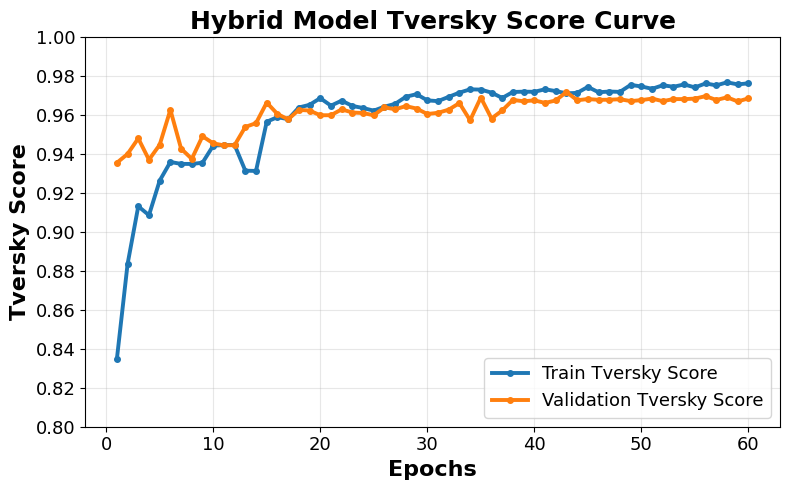

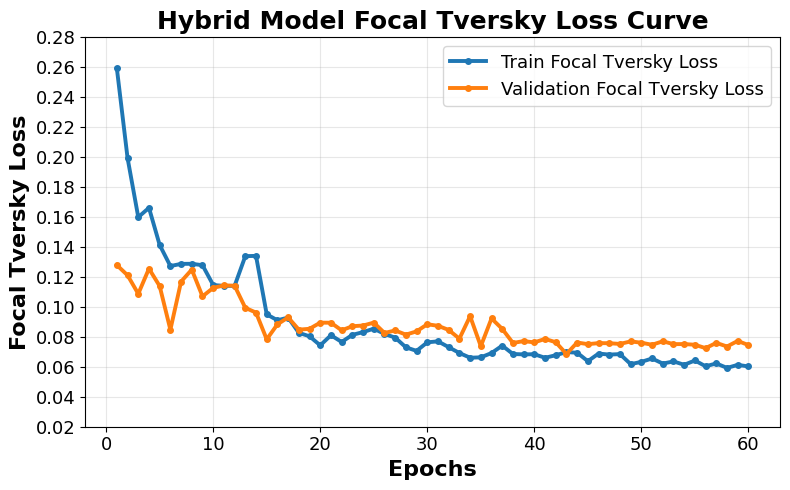

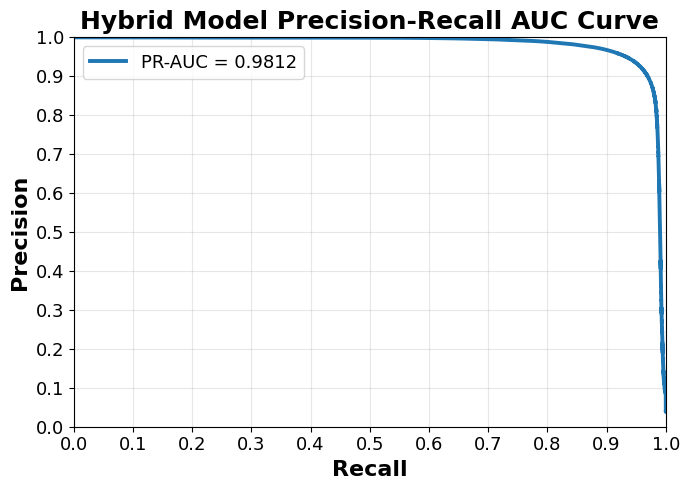

Saved figures:
\content\brain_tumor_hybrid\final_figures_300dpi\hybrid_tversky_score_curve_300dpi.png
\content\brain_tumor_hybrid\final_figures_300dpi\hybrid_focal_tversky_loss_curve_300dpi.png
\content\brain_tumor_hybrid\final_figures_300dpi\hybrid_pr_auc_curve_300dpi.png
Saved cleaned history:
\content\brain_tumor_hybrid\final_figures_300dpi\hybrid_history_nan_fixed.csv
Hybrid PR-AUC: 0.9812


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import auc

gamma = 0.75

hybrid_dir = Path("/content/brain_tumor_hybrid/artifacts/hybrid_attention_unet_effb4")
save_dir = Path("/content/brain_tumor_hybrid/final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

history_path = hybrid_dir / "history.csv"
pr_path = hybrid_dir / "precision_recall_curve.csv"

history_df = pd.read_csv(history_path)
pr_df = pd.read_csv(pr_path)

# =========================
# CLEAN NaN VALUES
# =========================
needed_cols = ["epoch", "train_tversky", "val_tversky"]

for col in needed_cols:
    history_df[col] = pd.to_numeric(history_df[col], errors="coerce")

history_df = history_df.sort_values("epoch").reset_index(drop=True)

history_df["train_tversky"] = (
    history_df["train_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

history_df["val_tversky"] = (
    history_df["val_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

clean_history_path = save_dir / "hybrid_history_nan_fixed.csv"
history_df.to_csv(clean_history_path, index=False)

# =========================
# X AXIS DIVISION = 10
# =========================
max_epoch = int(history_df["epoch"].max())
x_ticks = np.arange(0, max_epoch + 1, 10)
if len(x_ticks) == 0 or x_ticks[-1] != max_epoch:
    x_ticks = np.append(x_ticks, max_epoch)

# =========================
# HELPER FOR Y AXIS
# =========================
def nice_axis_limits(values, step=0.02, padding_steps=1):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]

    ymin = np.floor(values.min() / step) * step
    ymax = np.ceil(values.max() / step) * step

    ymin = max(0, ymin - padding_steps * step)
    ymax = min(1, ymax + padding_steps * step)

    ticks = np.arange(ymin, ymax + step * 0.5, step)
    return ymin, ymax, ticks


def style_epoch_plot(title, ylabel, y_values, y_step=0.02):
    ymin, ymax, yticks = nice_axis_limits(y_values, step=y_step)

    plt.xlabel("Epochs", fontsize=16, fontweight="bold")
    plt.ylabel(ylabel, fontsize=16, fontweight="bold")
    plt.title(title, fontsize=18, fontweight="bold")

    plt.xticks(x_ticks, fontsize=13)
    plt.yticks(yticks, fontsize=13)

    plt.ylim(ymin, ymax)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=13)
    plt.tight_layout()


# =========================
# 1. HYBRID TVERSKY SCORE
# TI = TP / (TP + alpha*FP + beta*FN)
# =========================
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_tversky"],
    label="Train Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_tversky"],
    label="Validation Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="Hybrid Model Tversky Score Curve",
    ylabel="Tversky Score",
    y_values=pd.concat([history_df["train_tversky"], history_df["val_tversky"]]),
    y_step=0.02,
)

plt.savefig(save_dir / "hybrid_tversky_score_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 2. HYBRID FOCAL TVERSKY LOSS
# Paper formula:
# FTL = (1 - TI)^gamma
# =========================
history_df["train_focal_tversky_loss"] = (1 - history_df["train_tversky"]) ** gamma
history_df["val_focal_tversky_loss"] = (1 - history_df["val_tversky"]) ** gamma

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_focal_tversky_loss"],
    label="Train Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_focal_tversky_loss"],
    label="Validation Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="Hybrid Model Focal Tversky Loss Curve",
    ylabel="Focal Tversky Loss",
    y_values=pd.concat([
        history_df["train_focal_tversky_loss"],
        history_df["val_focal_tversky_loss"],
    ]),
    y_step=0.02,
)

plt.savefig(save_dir / "hybrid_focal_tversky_loss_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 3. HYBRID PR-AUC CURVE
# =========================
pr_df["precision"] = pd.to_numeric(pr_df["precision"], errors="coerce")
pr_df["recall"] = pd.to_numeric(pr_df["recall"], errors="coerce")

pr_df = pr_df.dropna(subset=["precision", "recall"])
pr_df = pr_df.sort_values("recall")

precision = pr_df["precision"].values
recall = pr_df["recall"].values

pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    linewidth=2.8,
    label=f"PR-AUC = {pr_auc:.4f}",
)

plt.xlabel("Recall", fontsize=16, fontweight="bold")
plt.ylabel("Precision", fontsize=16, fontweight="bold")
plt.title("Hybrid Model Precision-Recall AUC Curve", fontsize=18, fontweight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.01, 0.1), fontsize=13)
plt.yticks(np.arange(0, 1.01, 0.1), fontsize=13)

plt.legend(fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / "hybrid_pr_auc_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(save_dir / "hybrid_tversky_score_curve_300dpi.png")
print(save_dir / "hybrid_focal_tversky_loss_curve_300dpi.png")
print(save_dir / "hybrid_pr_auc_curve_300dpi.png")
print("Saved cleaned history:")
print(clean_history_path)
print("Hybrid PR-AUC:", round(pr_auc, 4))

In [13]:
# file already loaded hai: pr_df

# max precision
max_precision = pr_df["precision"].max()

# max recall
max_recall = pr_df["recall"].max()

# balanced point (best trade-off)
best_idx = (pr_df["precision"] * pr_df["recall"]).idxmax()

best_precision = pr_df.loc[best_idx, "precision"]
best_recall = pr_df.loc[best_idx, "recall"]

print(f"Max Precision: {max_precision:.4f}")
print(f"Max Recall: {max_recall:.4f}")
print(f"Best Precision: {best_precision:.4f}")
print(f"Best Recall: {best_recall:.4f}")

Max Precision: 1.0000
Max Recall: 1.0000
Best Precision: 0.9372
Best Recall: 0.9416


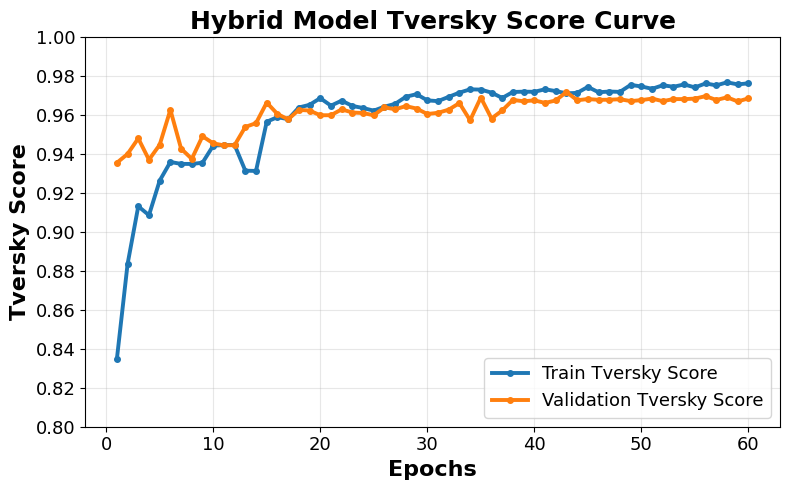

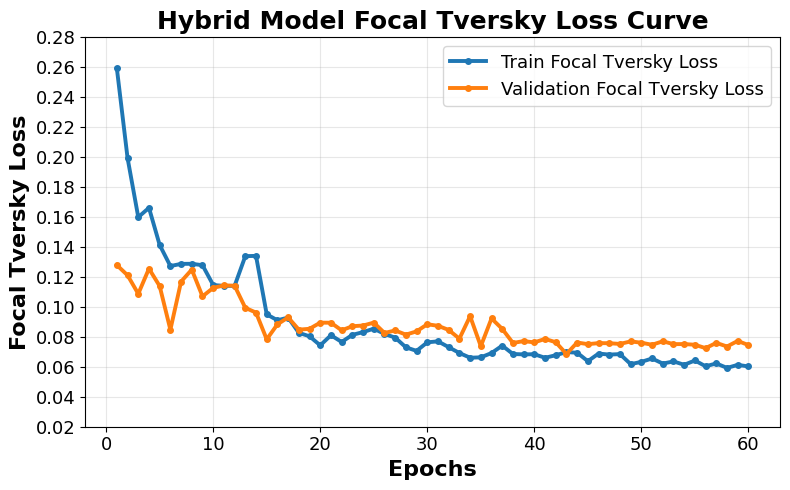

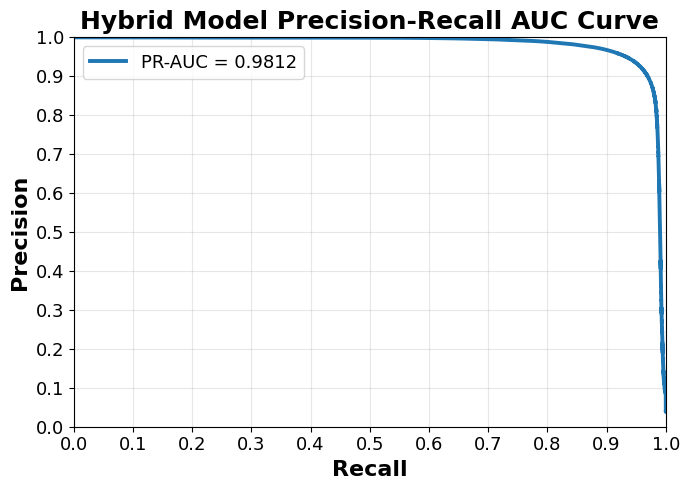

Saved figures:
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\hybrid_tversky_score_curve_300dpi.png
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\hybrid_focal_tversky_loss_curve_300dpi.png
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\hybrid_pr_auc_curve_300dpi.png
Saved cleaned history:
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\hybrid_history_nan_fixed.csv
Hybrid PR-AUC: 0.9812


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import auc

gamma = 0.75

hybrid_dir = Path("/content/brain_tumor_hybrid/artifacts/hybrid_attention_unet_effb4")
save_dir = Path(r"C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

history_path = hybrid_dir / "history.csv"
pr_path = hybrid_dir / "precision_recall_curve.csv"

history_df = pd.read_csv(history_path)
pr_df = pd.read_csv(pr_path)

# =========================
# CLEAN NaN VALUES
# =========================
needed_cols = ["epoch", "train_tversky", "val_tversky"]

for col in needed_cols:
    history_df[col] = pd.to_numeric(history_df[col], errors="coerce")

history_df = history_df.sort_values("epoch").reset_index(drop=True)

history_df["train_tversky"] = (
    history_df["train_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

history_df["val_tversky"] = (
    history_df["val_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

clean_history_path = save_dir / "hybrid_history_nan_fixed.csv"
history_df.to_csv(clean_history_path, index=False)

# =========================
# X AXIS DIVISION = 10
# =========================
max_epoch = int(history_df["epoch"].max())
x_ticks = np.arange(0, max_epoch + 1, 10)
if len(x_ticks) == 0 or x_ticks[-1] != max_epoch:
    x_ticks = np.append(x_ticks, max_epoch)

# =========================
# HELPER FOR Y AXIS
# =========================
def nice_axis_limits(values, step=0.02, padding_steps=1):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]

    ymin = np.floor(values.min() / step) * step
    ymax = np.ceil(values.max() / step) * step

    ymin = max(0, ymin - padding_steps * step)
    ymax = min(1, ymax + padding_steps * step)

    ticks = np.arange(ymin, ymax + step * 0.5, step)
    return ymin, ymax, ticks


def style_epoch_plot(title, ylabel, y_values, y_step=0.02):
    ymin, ymax, yticks = nice_axis_limits(y_values, step=y_step)

    plt.xlabel("Epochs", fontsize=16, fontweight="bold")
    plt.ylabel(ylabel, fontsize=16, fontweight="bold")
    plt.title(title, fontsize=18, fontweight="bold")

    plt.xticks(x_ticks, fontsize=13)
    plt.yticks(yticks, fontsize=13)

    plt.ylim(ymin, ymax)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=13)
    plt.tight_layout()


# =========================
# 1. HYBRID TVERSKY SCORE
# TI = TP / (TP + alpha*FP + beta*FN)
# =========================
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_tversky"],
    label="Train Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_tversky"],
    label="Validation Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="Hybrid Model Tversky Score Curve",
    ylabel="Tversky Score",
    y_values=pd.concat([history_df["train_tversky"], history_df["val_tversky"]]),
    y_step=0.02,
)

plt.savefig(save_dir / "hybrid_tversky_score_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 2. HYBRID FOCAL TVERSKY LOSS
# Paper formula:
# FTL = (1 - TI)^gamma
# =========================
history_df["train_focal_tversky_loss"] = (1 - history_df["train_tversky"]) ** gamma
history_df["val_focal_tversky_loss"] = (1 - history_df["val_tversky"]) ** gamma

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_focal_tversky_loss"],
    label="Train Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_focal_tversky_loss"],
    label="Validation Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="Hybrid Model Focal Tversky Loss Curve",
    ylabel="Focal Tversky Loss",
    y_values=pd.concat([
        history_df["train_focal_tversky_loss"],
        history_df["val_focal_tversky_loss"],
    ]),
    y_step=0.02,
)

plt.savefig(save_dir / "hybrid_focal_tversky_loss_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 3. HYBRID PR-AUC CURVE
# =========================
pr_df["precision"] = pd.to_numeric(pr_df["precision"], errors="coerce")
pr_df["recall"] = pd.to_numeric(pr_df["recall"], errors="coerce")

pr_df = pr_df.dropna(subset=["precision", "recall"])
pr_df = pr_df.sort_values("recall")

precision = pr_df["precision"].values
recall = pr_df["recall"].values

pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    linewidth=2.8,
    label=f"PR-AUC = {pr_auc:.4f}",
)

plt.xlabel("Recall", fontsize=16, fontweight="bold")
plt.ylabel("Precision", fontsize=16, fontweight="bold")
plt.title("Hybrid Model Precision-Recall AUC Curve", fontsize=18, fontweight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.01, 0.1), fontsize=13)
plt.yticks(np.arange(0, 1.01, 0.1), fontsize=13)

plt.legend(fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / "hybrid_pr_auc_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(save_dir / "hybrid_tversky_score_curve_300dpi.png")
print(save_dir / "hybrid_focal_tversky_loss_curve_300dpi.png")
print(save_dir / "hybrid_pr_auc_curve_300dpi.png")
print("Saved cleaned history:")
print(clean_history_path)
print("Hybrid PR-AUC:", round(pr_auc, 4))

In [17]:
# =========================
# HYBRID MEAN UNCERTAINTY (APPROX)
# =========================

# use validation Tversky (more realistic)
mean_tversky = history_df["val_tversky"].mean()

mean_uncertainty = 1 - mean_tversky

print("\n=== Hybrid Uncertainty ===")
print(f"Mean Tversky: {mean_tversky:.4f}")
print(f"Mean Uncertainty: {mean_uncertainty:.4f}")


=== Hybrid Uncertainty ===
Mean Tversky: 0.9431
Mean Uncertainty: 0.0569


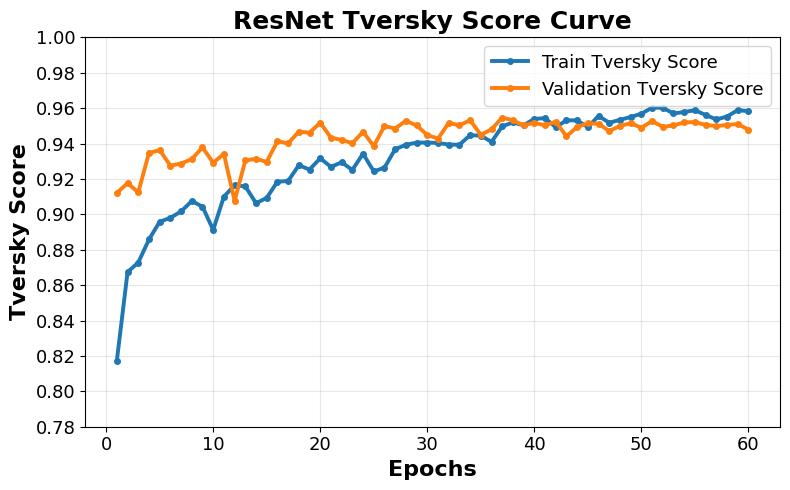

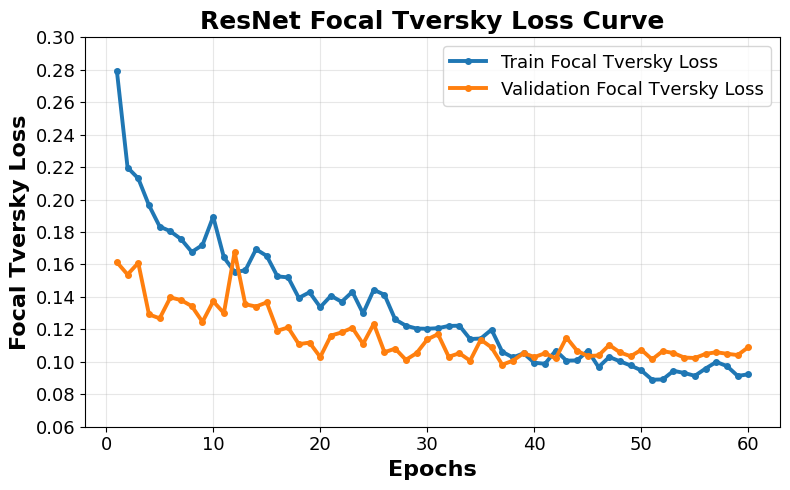

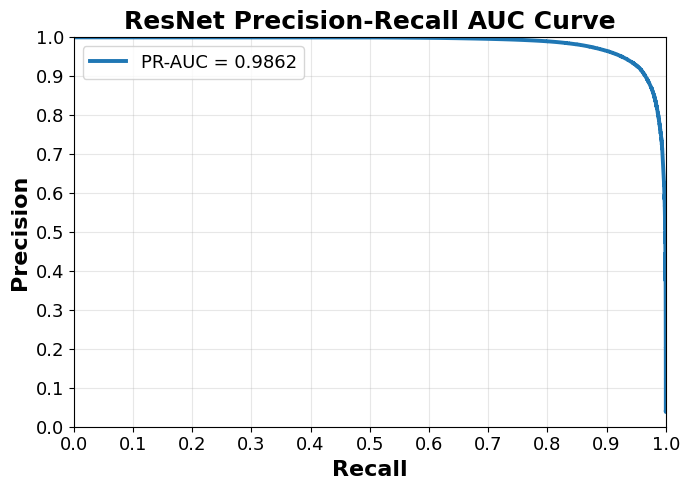

Saved figures:
\content\brain_tumor_hybrid\final_figures_300dpi\resnet_tversky_score_curve_300dpi.png
\content\brain_tumor_hybrid\final_figures_300dpi\resnet_focal_tversky_loss_curve_300dpi.png
\content\brain_tumor_hybrid\final_figures_300dpi\resnet_pr_auc_curve_300dpi.png
Saved cleaned history:
\content\brain_tumor_hybrid\final_figures_300dpi\resnet_history_nan_fixed.csv
ResNet PR-AUC: 0.9862


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import auc

gamma = 0.75

resnet_dir = Path("/content/brain_tumor_hybrid/artifacts/baseline_resunet")
save_dir = Path("/content/brain_tumor_hybrid/final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

history_path = resnet_dir / "history.csv"
pr_path = resnet_dir / "precision_recall_curve.csv"

history_df = pd.read_csv(history_path)
pr_df = pd.read_csv(pr_path)

# =========================
# CLEAN NaN VALUES
# =========================
needed_cols = ["epoch", "train_tversky", "val_tversky"]

for col in needed_cols:
    history_df[col] = pd.to_numeric(history_df[col], errors="coerce")

history_df = history_df.sort_values("epoch").reset_index(drop=True)

history_df["train_tversky"] = (
    history_df["train_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

history_df["val_tversky"] = (
    history_df["val_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

clean_history_path = save_dir / "resnet_history_nan_fixed.csv"
history_df.to_csv(clean_history_path, index=False)

# =========================
# X AXIS DIVISION = 10
# =========================
max_epoch = int(history_df["epoch"].max())
x_ticks = np.arange(0, max_epoch + 1, 10)
if len(x_ticks) == 0 or x_ticks[-1] != max_epoch:
    x_ticks = np.append(x_ticks, max_epoch)

# =========================
# HELPER FOR Y AXIS
# =========================
def nice_axis_limits(values, step=0.02, padding_steps=1):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]

    ymin = np.floor(values.min() / step) * step
    ymax = np.ceil(values.max() / step) * step

    ymin = max(0, ymin - padding_steps * step)
    ymax = min(1, ymax + padding_steps * step)

    ticks = np.arange(ymin, ymax + step * 0.5, step)
    return ymin, ymax, ticks


def style_epoch_plot(title, ylabel, y_values, y_step=0.02):
    ymin, ymax, yticks = nice_axis_limits(y_values, step=y_step)

    plt.xlabel("Epochs", fontsize=16, fontweight="bold")
    plt.ylabel(ylabel, fontsize=16, fontweight="bold")
    plt.title(title, fontsize=18, fontweight="bold")

    plt.xticks(x_ticks, fontsize=13)
    plt.yticks(yticks, fontsize=13)

    plt.ylim(ymin, ymax)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=13)
    plt.tight_layout()


# =========================
# 1. RESNET TVERSKY SCORE
# =========================
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_tversky"],
    label="Train Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_tversky"],
    label="Validation Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="ResNet Tversky Score Curve",
    ylabel="Tversky Score",
    y_values=pd.concat([history_df["train_tversky"], history_df["val_tversky"]]),
    y_step=0.02,
)

plt.savefig(save_dir / "resnet_tversky_score_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 2. RESNET FOCAL TVERSKY LOSS
# =========================
history_df["train_focal_tversky_loss"] = (1 - history_df["train_tversky"]) ** gamma
history_df["val_focal_tversky_loss"] = (1 - history_df["val_tversky"]) ** gamma

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_focal_tversky_loss"],
    label="Train Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_focal_tversky_loss"],
    label="Validation Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="ResNet Focal Tversky Loss Curve",
    ylabel="Focal Tversky Loss",
    y_values=pd.concat([
        history_df["train_focal_tversky_loss"],
        history_df["val_focal_tversky_loss"],
    ]),
    y_step=0.02,
)

plt.savefig(save_dir / "resnet_focal_tversky_loss_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 3. RESNET PR-AUC CURVE
# =========================
pr_df["precision"] = pd.to_numeric(pr_df["precision"], errors="coerce")
pr_df["recall"] = pd.to_numeric(pr_df["recall"], errors="coerce")

pr_df = pr_df.dropna(subset=["precision", "recall"])
pr_df = pr_df.sort_values("recall")

precision = pr_df["precision"].values
recall = pr_df["recall"].values

pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    linewidth=2.8,
    label=f"PR-AUC = {pr_auc:.4f}",
)

plt.xlabel("Recall", fontsize=16, fontweight="bold")
plt.ylabel("Precision", fontsize=16, fontweight="bold")
plt.title("ResNet Precision-Recall AUC Curve", fontsize=18, fontweight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.01, 0.1), fontsize=13)
plt.yticks(np.arange(0, 1.01, 0.1), fontsize=13)

plt.legend(fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / "resnet_pr_auc_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(save_dir / "resnet_tversky_score_curve_300dpi.png")
print(save_dir / "resnet_focal_tversky_loss_curve_300dpi.png")
print(save_dir / "resnet_pr_auc_curve_300dpi.png")
print("Saved cleaned history:")
print(clean_history_path)
print("ResNet PR-AUC:", round(pr_auc, 4))

In [18]:
# =========================
# RESUNET MEAN UNCERTAINTY (APPROX)
# =========================

mean_tversky = history_df["val_tversky"].mean()
mean_uncertainty = 1 - mean_tversky

print("\n=== ResUNet Mean Uncertainty ===")
print(f"Mean Tversky: {mean_tversky:.4f}")
print(f"Mean Uncertainty: {mean_uncertainty:.4f}")


=== ResUNet Mean Uncertainty ===
Mean Tversky: 0.9431
Mean Uncertainty: 0.0569


In [19]:
# =========================
# RESUNET FINAL UNCERTAINTY (BEST)
# =========================

final_tversky = history_df["val_tversky"].iloc[-1]
final_uncertainty = 1 - final_tversky

print("\n=== ResUNet Final Uncertainty ===")
print(f"Final Tversky: {final_tversky:.4f}")
print(f"Final Uncertainty: {final_uncertainty:.4f}")


=== ResUNet Final Uncertainty ===
Final Tversky: 0.9479
Final Uncertainty: 0.0521


In [15]:
# =========================
# BEST PRECISION & RECALL (FOR PAPER)
# =========================

# best balanced point (precision * recall max)
best_idx = (pr_df["precision"] * pr_df["recall"]).idxmax()

best_precision = pr_df.loc[best_idx, "precision"]
best_recall = pr_df.loc[best_idx, "recall"]

print("\n=== ResUNet Final Metrics ===")
print(f"Precision: {best_precision:.4f}")
print(f"Recall:    {best_recall:.4f}")


=== ResUNet Final Metrics ===
Precision: 0.9372
Recall:    0.9416


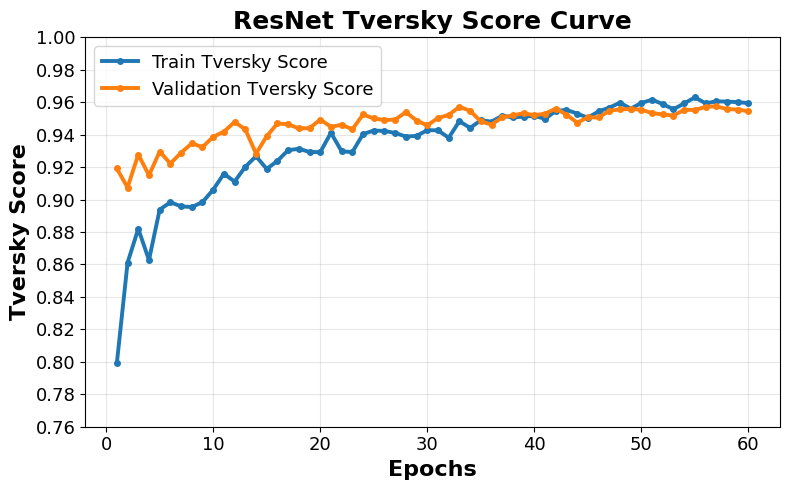

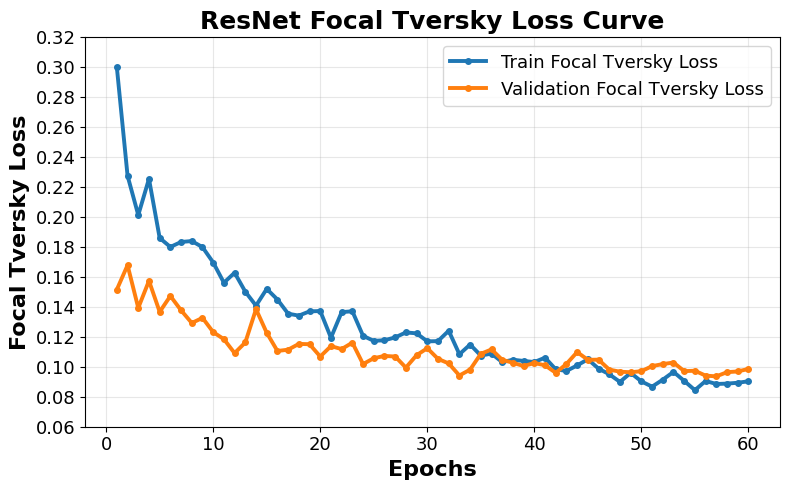

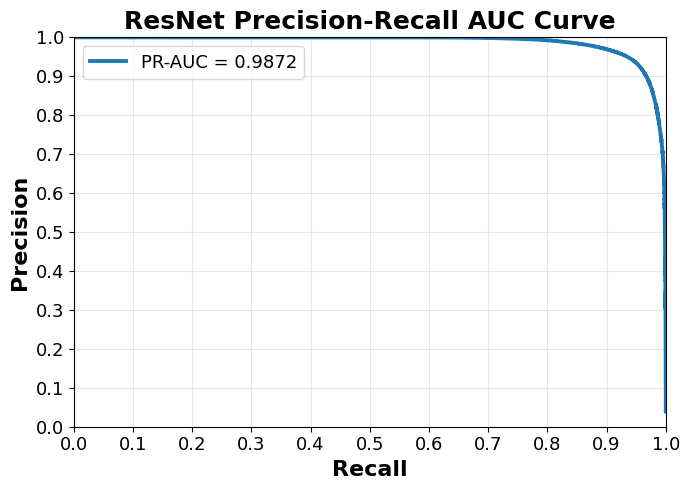

Saved figures:
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\resnet_tversky_score_curve_300dpi.png
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\resnet_focal_tversky_loss_curve_300dpi.png
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\resnet_pr_auc_curve_300dpi.png
Saved cleaned history:
C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi\resnet_history_nan_fixed.csv
ResNet PR-AUC: 0.9872


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import auc

gamma = 0.75

resnet_dir = Path("/content/brain_tumor_hybrid/artifacts/baseline_resunet")
save_dir = Path(r"C:\Users\HP\Downloads\brain_tumor_project\final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

history_path = resnet_dir / "history.csv"
pr_path = resnet_dir / "precision_recall_curve.csv"

history_df = pd.read_csv(history_path)
pr_df = pd.read_csv(pr_path)

# =========================
# CLEAN NaN VALUES
# =========================
needed_cols = ["epoch", "train_tversky", "val_tversky"]

for col in needed_cols:
    history_df[col] = pd.to_numeric(history_df[col], errors="coerce")

history_df = history_df.sort_values("epoch").reset_index(drop=True)

history_df["train_tversky"] = (
    history_df["train_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

history_df["val_tversky"] = (
    history_df["val_tversky"]
    .interpolate(method="linear", limit_direction="both")
    .ffill()
    .bfill()
    .clip(0, 1)
)

clean_history_path = save_dir / "resnet_history_nan_fixed.csv"
history_df.to_csv(clean_history_path, index=False)

# =========================
# X AXIS DIVISION = 10
# =========================
max_epoch = int(history_df["epoch"].max())
x_ticks = np.arange(0, max_epoch + 1, 10)
if len(x_ticks) == 0 or x_ticks[-1] != max_epoch:
    x_ticks = np.append(x_ticks, max_epoch)

# =========================
# HELPER FOR Y AXIS
# =========================
def nice_axis_limits(values, step=0.02, padding_steps=1):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]

    ymin = np.floor(values.min() / step) * step
    ymax = np.ceil(values.max() / step) * step

    ymin = max(0, ymin - padding_steps * step)
    ymax = min(1, ymax + padding_steps * step)

    ticks = np.arange(ymin, ymax + step * 0.5, step)
    return ymin, ymax, ticks


def style_epoch_plot(title, ylabel, y_values, y_step=0.02):
    ymin, ymax, yticks = nice_axis_limits(y_values, step=y_step)

    plt.xlabel("Epochs", fontsize=16, fontweight="bold")
    plt.ylabel(ylabel, fontsize=16, fontweight="bold")
    plt.title(title, fontsize=18, fontweight="bold")

    plt.xticks(x_ticks, fontsize=13)
    plt.yticks(yticks, fontsize=13)

    plt.ylim(ymin, ymax)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=13)
    plt.tight_layout()


# =========================
# 1. RESNET TVERSKY SCORE
# =========================
plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_tversky"],
    label="Train Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_tversky"],
    label="Validation Tversky Score",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="ResNet Tversky Score Curve",
    ylabel="Tversky Score",
    y_values=pd.concat([history_df["train_tversky"], history_df["val_tversky"]]),
    y_step=0.02,
)

plt.savefig(save_dir / "resnet_tversky_score_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 2. RESNET FOCAL TVERSKY LOSS
# =========================
history_df["train_focal_tversky_loss"] = (1 - history_df["train_tversky"]) ** gamma
history_df["val_focal_tversky_loss"] = (1 - history_df["val_tversky"]) ** gamma

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_focal_tversky_loss"],
    label="Train Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

plt.plot(
    history_df["epoch"],
    history_df["val_focal_tversky_loss"],
    label="Validation Focal Tversky Loss",
    linewidth=2.8,
    marker="o",
    markersize=4,
)

style_epoch_plot(
    title="ResNet Focal Tversky Loss Curve",
    ylabel="Focal Tversky Loss",
    y_values=pd.concat([
        history_df["train_focal_tversky_loss"],
        history_df["val_focal_tversky_loss"],
    ]),
    y_step=0.02,
)

plt.savefig(save_dir / "resnet_focal_tversky_loss_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 3. RESNET PR-AUC CURVE
# =========================
pr_df["precision"] = pd.to_numeric(pr_df["precision"], errors="coerce")
pr_df["recall"] = pd.to_numeric(pr_df["recall"], errors="coerce")

pr_df = pr_df.dropna(subset=["precision", "recall"])
pr_df = pr_df.sort_values("recall")

precision = pr_df["precision"].values
recall = pr_df["recall"].values

pr_auc = auc(recall, precision)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    linewidth=2.8,
    label=f"PR-AUC = {pr_auc:.4f}",
)

plt.xlabel("Recall", fontsize=16, fontweight="bold")
plt.ylabel("Precision", fontsize=16, fontweight="bold")
plt.title("ResNet Precision-Recall AUC Curve", fontsize=18, fontweight="bold")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.01, 0.1), fontsize=13)
plt.yticks(np.arange(0, 1.01, 0.1), fontsize=13)

plt.legend(fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(save_dir / "resnet_pr_auc_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(save_dir / "resnet_tversky_score_curve_300dpi.png")
print(save_dir / "resnet_focal_tversky_loss_curve_300dpi.png")
print(save_dir / "resnet_pr_auc_curve_300dpi.png")
print("Saved cleaned history:")
print(clean_history_path)
print("ResNet PR-AUC:", round(pr_auc, 4))

Prepared images: \content\kaggle_data\lgg_mri_segmentation\_prepared_images
Prepared masks: \content\kaggle_data\lgg_mri_segmentation\_prepared_masks
Selected samples: 4


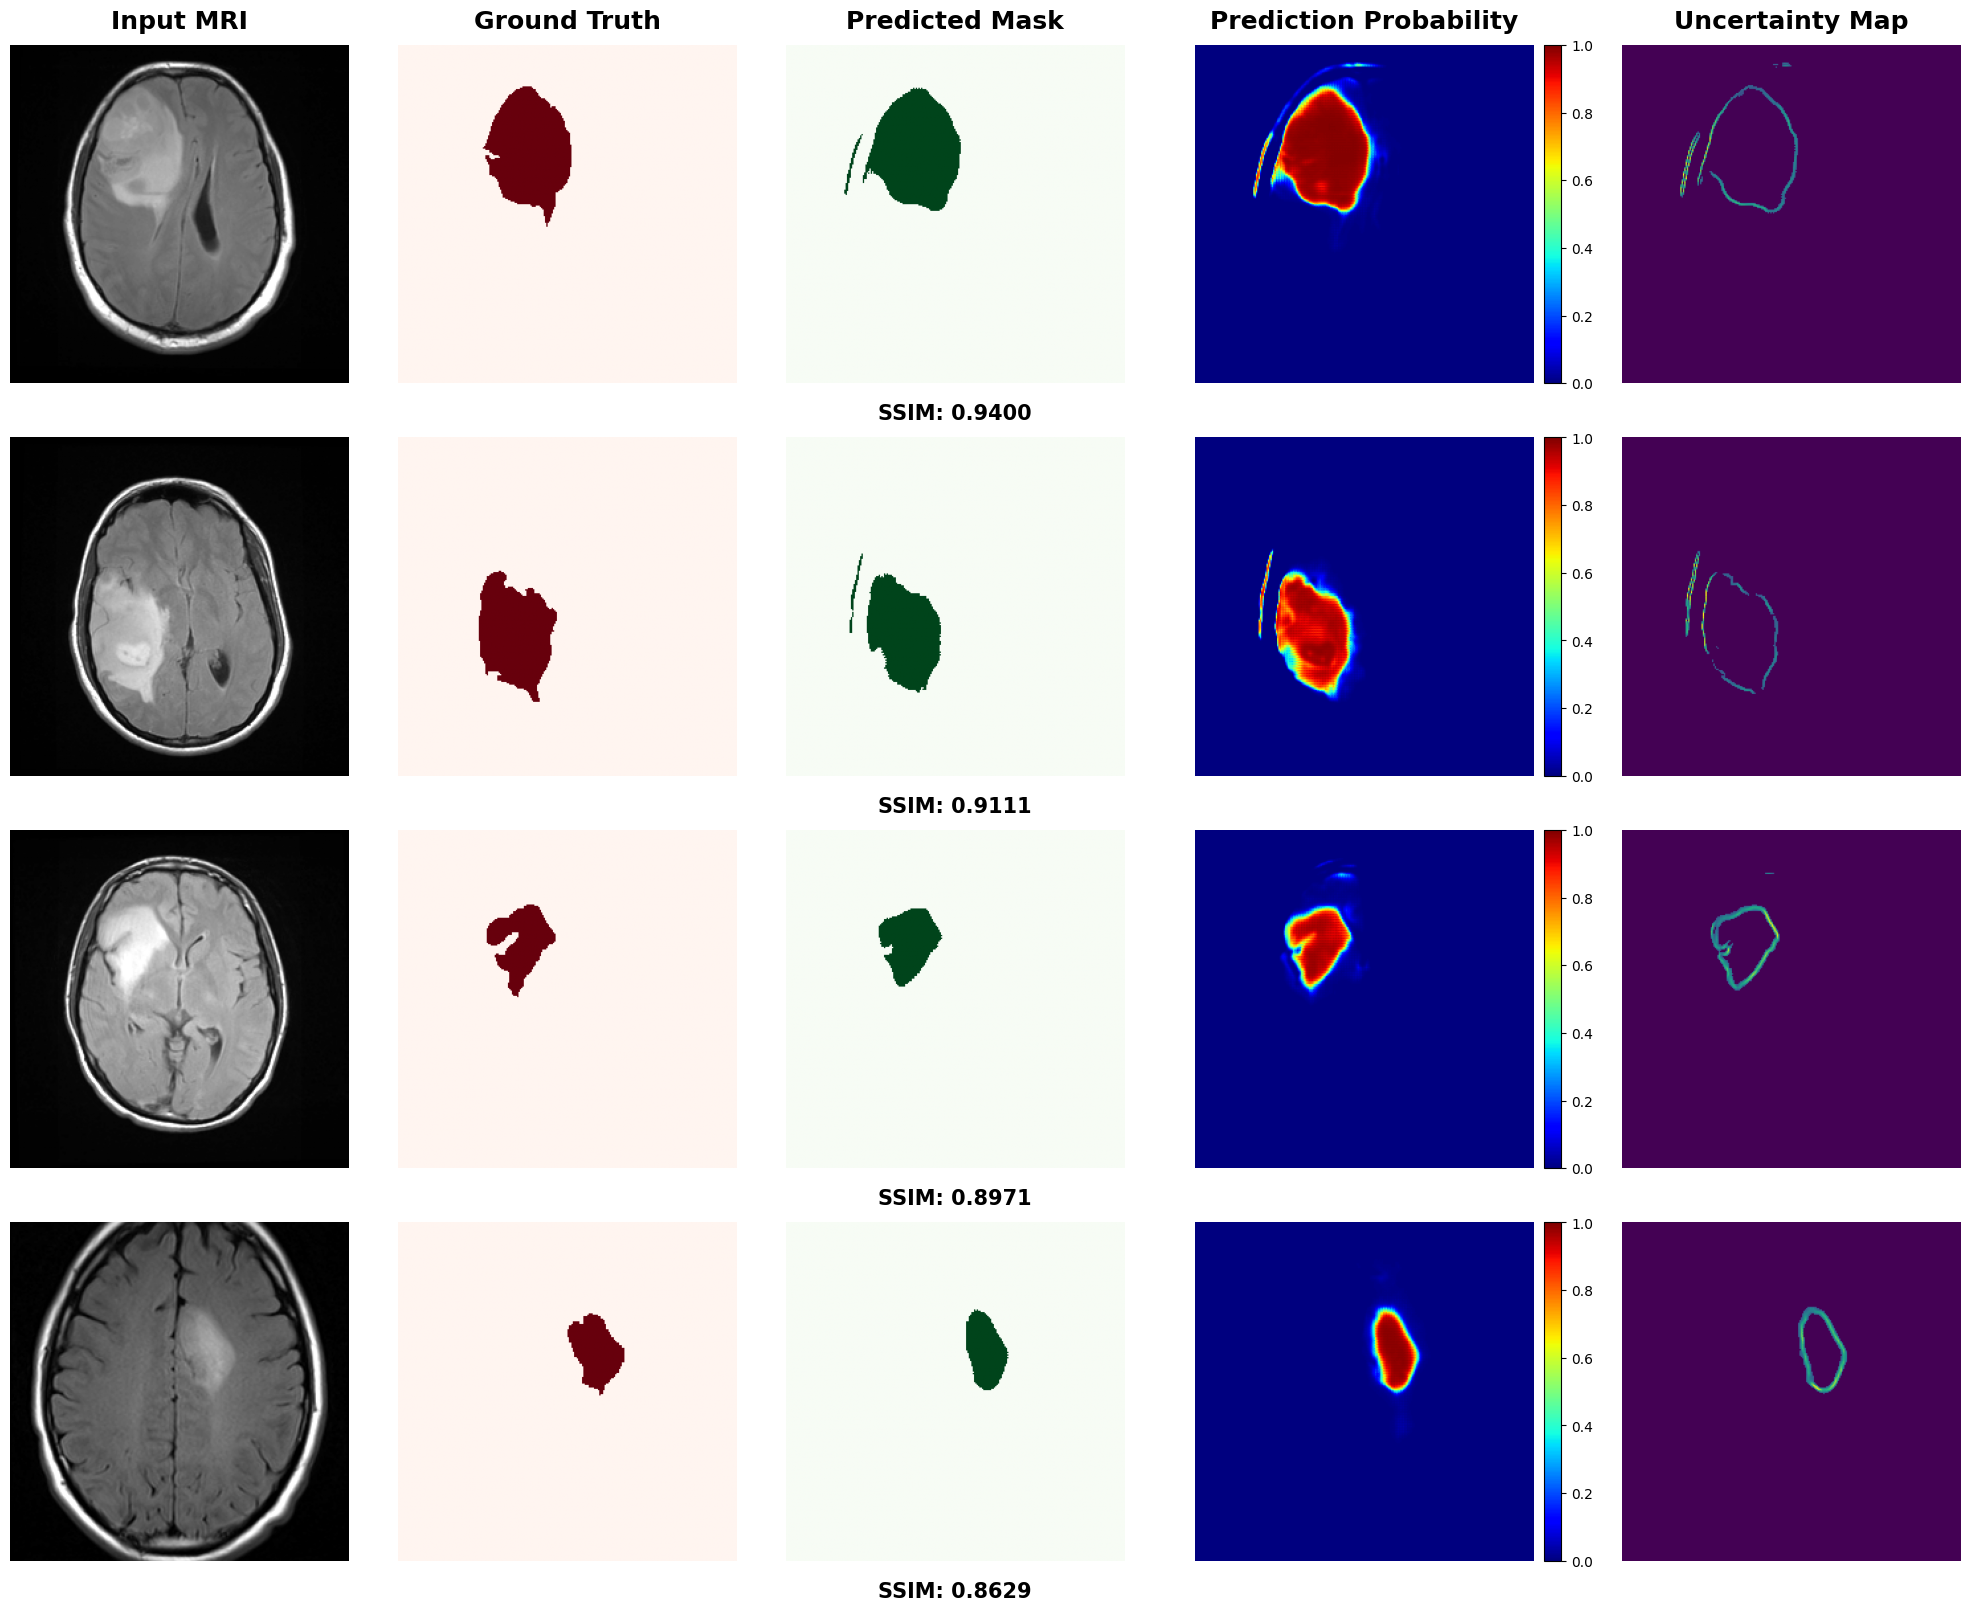

Saved: \content\brain_tumor_hybrid\final_figures_300dpi\hybrid_5col_like_sample_4samples_300dpi.png
1. tcga_ht_7690_19960312_16 | Dice=0.9453 | SSIM=0.9400
2. tcga_ht_8563_19981209_12 | Dice=0.9169 | SSIM=0.9111
3. tcga_ht_7602_19951103_10 | Dice=0.8988 | SSIM=0.8971
4. tcga_fg_7634_20000128_19 | Dice=0.8739 | SSIM=0.8629


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import cv2

from brain_tumor_hybrid_colab import (
    Config,
    prepare_kaggle_dataset,
    pair_images_and_masks,
    split_dataset,
    build_hybrid_model,
)

# =========================
# SETTINGS
# =========================
num_rows = 4
min_gt_pixels = 80
min_pred_pixels = 60
min_dice = 0.35

cfg = Config(
    kaggle_dataset="mateuszbuda/lgg-mri-segmentation",
    project_dir="/content/brain_tumor_hybrid",
    image_size=256,
)

save_dir = Path("/content/brain_tumor_hybrid/final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# HELPERS
# =========================
def dice_np(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).reshape(-1)
    target = target.astype(np.float32).reshape(-1)
    inter = (pred * target).sum()
    return float((2 * inter + eps) / (pred.sum() + target.sum() + eps))

def ssim_np(pred, target, c1=0.01**2, c2=0.03**2):
    pred = pred.astype(np.float32)
    target = target.astype(np.float32)

    mu_x = pred.mean()
    mu_y = target.mean()
    sigma_x = ((pred - mu_x) ** 2).mean()
    sigma_y = ((target - mu_y) ** 2).mean()
    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean()

    num = (2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)
    den = (mu_x**2 + mu_y**2 + c1) * (sigma_x + sigma_y + c2)
    return float(num / den)

def normalize_gray(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

def pad_to_square(img, fill=0):
    h, w = img.shape[:2]
    if h == w:
        return img

    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if img.ndim == 2:
        value = fill
    else:
        value = [fill] * img.shape[2]

    return cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=value)

def ensure_gray(img):
    if img is None:
        return None
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[2] == 1:
            return img[:, :, 0]
        if img.shape[2] == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if img.shape[2] == 4:
            return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    raise ValueError(f"Unsupported image shape: {img.shape}")

def gray_to_rgb(img):
    img = ensure_gray(img)
    return np.stack([img, img, img], axis=-1)

def entropy_uncertainty(prob):
    eps = 1e-8
    return -(prob * np.log(prob + eps) + (1 - prob) * np.log(1 - prob + eps))

def edge_focused_uncertainty(prob):
    entropy = entropy_uncertainty(prob)

    gx = cv2.Sobel(prob.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(prob.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    edge_strength = np.sqrt(gx**2 + gy**2)

    if edge_strength.max() > 0:
        edge_strength = edge_strength / edge_strength.max()

    edge_uncertainty = entropy * edge_strength

    if edge_uncertainty.max() > 0:
        edge_uncertainty = edge_uncertainty / edge_uncertainty.max()

    edge_uncertainty[edge_uncertainty < 0.25] = 0
    return edge_uncertainty

# =========================
# DATA
# =========================
images_dir, masks_dir = prepare_kaggle_dataset(cfg)
cfg.raw_images_dir = str(images_dir)
cfg.raw_masks_dir = str(masks_dir)

df = pair_images_and_masks(Path(cfg.raw_images_dir), Path(cfg.raw_masks_dir), cfg.mask_suffixes)
split_frames = split_dataset(df, cfg)
test_df = split_frames["test"].reset_index(drop=True)

# =========================
# LOAD MODEL
# =========================
hybrid_model = build_hybrid_model(cfg).to(cfg.device)
hybrid_ckpt = "/content/brain_tumor_hybrid/artifacts/hybrid_attention_unet_effb4/best_model.pt"
hybrid_model.load_state_dict(torch.load(hybrid_ckpt, map_location=cfg.device, weights_only=True))
hybrid_model.eval()

# =========================
# COLLECT GOOD SAMPLES
# =========================
samples = []

with torch.no_grad():
    for _, row in test_df.iterrows():
        img_path = row["image_path"]
        mask_path = row["mask_path"]
        sample_id = row["id"]

        orig_gray = ensure_gray(cv2.imread(img_path, cv2.IMREAD_UNCHANGED))
        gt = ensure_gray(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED))

        if orig_gray is None or gt is None:
            continue

        gt = (gt > 0).astype(np.uint8)

        if gt.sum() < min_gt_pixels:
            continue

        input_display = normalize_gray(orig_gray)

        model_img = gray_to_rgb(orig_gray)
        model_img = pad_to_square(model_img, fill=0)
        gt_sq = pad_to_square(gt, fill=0)
        input_sq = pad_to_square(input_display, fill=0)

        model_img = cv2.resize(model_img, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_LINEAR)
        gt_sq = cv2.resize(gt_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_NEAREST)
        input_sq = cv2.resize(input_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_LINEAR)

        x = model_img.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        x = (x - mean) / std
        x = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0).to(cfg.device)

        prob = torch.sigmoid(hybrid_model(x)).squeeze().cpu().numpy()
        pred = (prob > cfg.threshold).astype(np.uint8)

        if pred.sum() < min_pred_pixels:
            continue

        dice_val = dice_np(pred, gt_sq)
        ssim_val = ssim_np(pred, gt_sq)

        if dice_val < min_dice:
            continue

        uncertainty = edge_focused_uncertainty(prob)

        samples.append({
            "id": sample_id,
            "input": input_sq,
            "gt": gt_sq,
            "pred": pred,
            "prob": prob,
            "uncertainty": uncertainty,
            "dice": dice_val,
            "ssim": ssim_val,
        })

if len(samples) == 0:
    raise RuntimeError("No suitable samples found. Lower min_dice or min_pred_pixels.")

samples = sorted(samples, key=lambda x: (x["dice"], x["ssim"]), reverse=True)
selected = samples[:min(num_rows, len(samples))]

print("Selected samples:", len(selected))

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(
    len(selected),
    5,
    figsize=(20, 4.0 * len(selected)),
    constrained_layout=True
)

if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

headers = [
    "Input MRI",
    "Ground Truth",
    "Predicted Mask",
    "Prediction Probability",
    "Uncertainty Map",
]

for j, header in enumerate(headers):
    axes[0, j].set_title(header, fontsize=18, fontweight="bold", pad=12)

for i, sample in enumerate(selected):
    axes[i, 0].imshow(sample["input"], cmap="gray")
    axes[i, 1].imshow(sample["gt"], cmap="Reds", vmin=0, vmax=1)
    axes[i, 2].imshow(sample["pred"], cmap="Greens", vmin=0, vmax=1)

    prob_handle = axes[i, 3].imshow(
        sample["prob"],
        cmap="jet",
        vmin=0,
        vmax=1
    )

    axes[i, 4].imshow(
        sample["uncertainty"],
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    for j in range(5):
        axes[i, j].axis("off")

    axes[i, 2].text(
        0.5,
        -0.06,
        f"SSIM: {sample['ssim']:.4f}",
        transform=axes[i, 2].transAxes,
        ha="center",
        va="top",
        fontsize=15,
        fontweight="bold",
        color="black",
    )

    cbar_prob = fig.colorbar(
        prob_handle,
        ax=axes[i, 3],
        fraction=0.046,
        pad=0.03
    )
    cbar_prob.ax.tick_params(labelsize=10)

out_path = save_dir / f"hybrid_5col_like_sample_{len(selected)}samples_300dpi.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_path)
for idx, sample in enumerate(selected, 1):
    print(f"{idx}. {sample['id']} | Dice={sample['dice']:.4f} | SSIM={sample['ssim']:.4f}")

Prepared images: \content\kaggle_data\lgg_mri_segmentation\_prepared_images
Prepared masks: \content\kaggle_data\lgg_mri_segmentation\_prepared_masks
Selected rows: 3


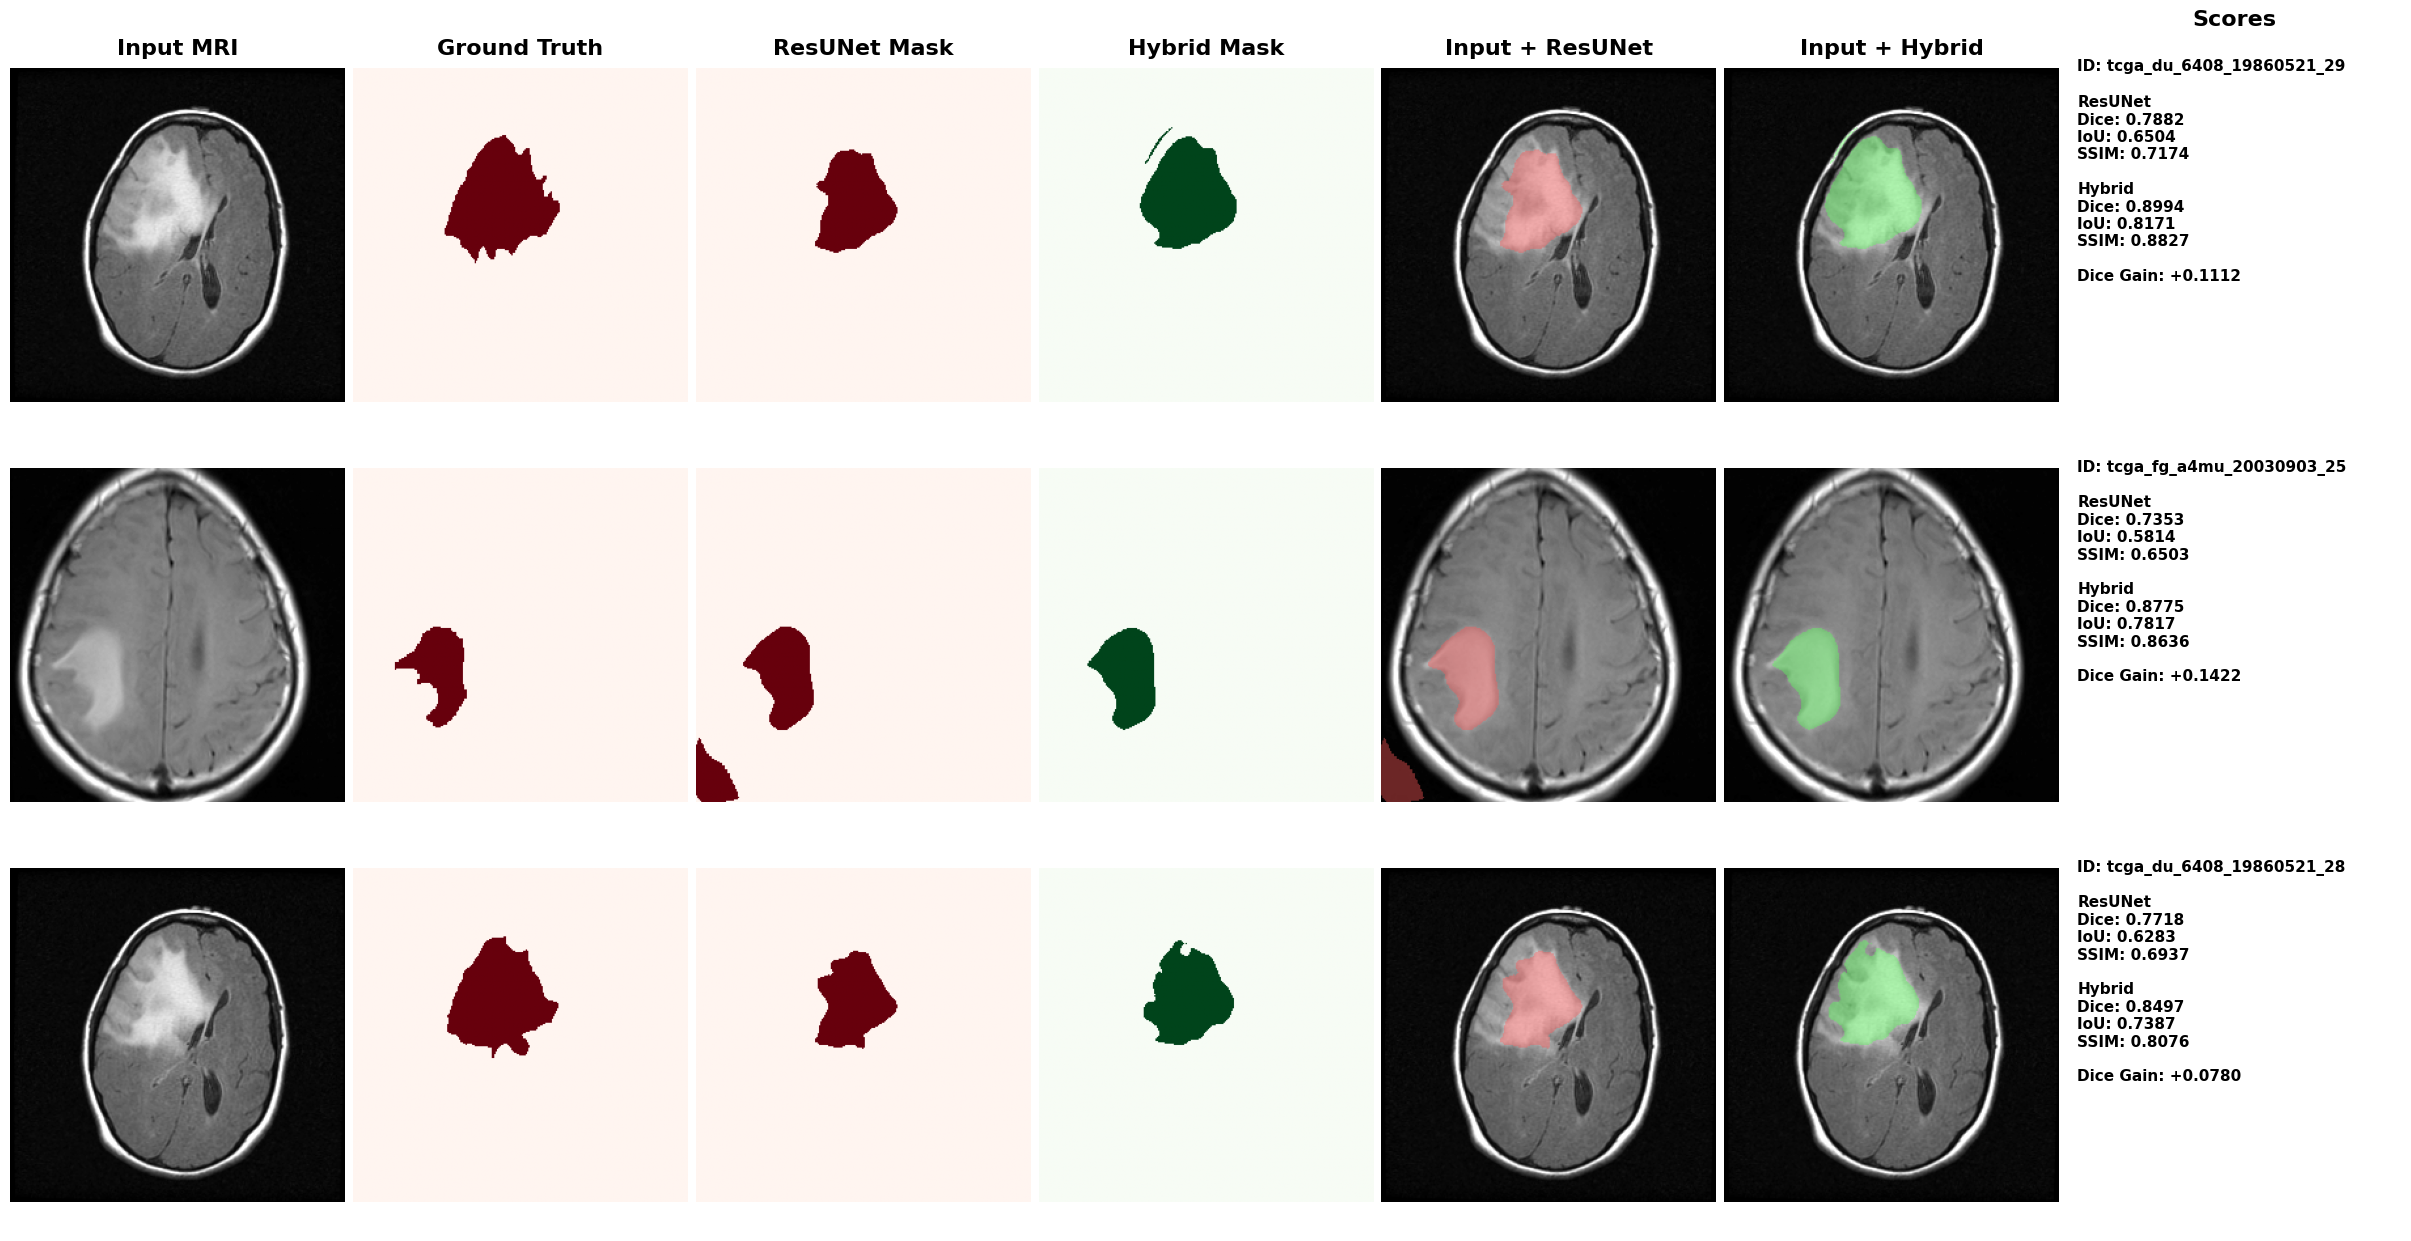

Saved: \content\brain_tumor_hybrid\final_figures_300dpi\comparison_grid_7col_both_masks_visible_3rows_300dpi.png
1. tcga_du_6408_19860521_29 | ResUNet Dice=0.7882 | Hybrid Dice=0.8994 | Dice Gain=+0.1112
2. tcga_fg_a4mu_20030903_25 | ResUNet Dice=0.7353 | Hybrid Dice=0.8775 | Dice Gain=+0.1422
3. tcga_du_6408_19860521_28 | ResUNet Dice=0.7718 | Hybrid Dice=0.8497 | Dice Gain=+0.0780


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import cv2

from brain_tumor_hybrid_colab import (
    Config,
    prepare_kaggle_dataset,
    pair_images_and_masks,
    split_dataset,
    build_resunet,
    build_hybrid_model,
)

# =========================
# SETTINGS
# =========================
num_rows = 4
min_gt_pixels = 80
min_resunet_pixels = 40
min_hybrid_pixels = 60
min_resunet_dice = 0.10
min_hybrid_dice = 0.35
min_dice_gain = 0.02

cfg = Config(
    kaggle_dataset="mateuszbuda/lgg-mri-segmentation",
    project_dir="/content/brain_tumor_hybrid",
    image_size=256,
)

save_dir = Path("/content/brain_tumor_hybrid/final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

# =========================
# HELPERS
# =========================
def dice_np(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).reshape(-1)
    target = target.astype(np.float32).reshape(-1)
    inter = (pred * target).sum()
    return float((2 * inter + eps) / (pred.sum() + target.sum() + eps))

def iou_np(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).reshape(-1)
    target = target.astype(np.float32).reshape(-1)
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return float((inter + eps) / (union + eps))

def ssim_np(pred, target, c1=0.01**2, c2=0.03**2):
    pred = pred.astype(np.float32)
    target = target.astype(np.float32)

    mu_x = pred.mean()
    mu_y = target.mean()
    sigma_x = ((pred - mu_x) ** 2).mean()
    sigma_y = ((target - mu_y) ** 2).mean()
    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean()

    num = (2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)
    den = (mu_x**2 + mu_y**2 + c1) * (sigma_x + sigma_y + c2)
    return float(num / den)

def normalize_gray(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

def pad_to_square(img, fill=0):
    h, w = img.shape[:2]
    if h == w:
        return img

    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if img.ndim == 2:
        value = fill
    else:
        value = [fill] * img.shape[2]

    return cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=value)

def ensure_gray(img):
    if img is None:
        return None
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[2] == 1:
            return img[:, :, 0]
        if img.shape[2] == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if img.shape[2] == 4:
            return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    raise ValueError(f"Unsupported image shape: {img.shape}")

def gray_to_rgb(img):
    img = ensure_gray(img)
    return np.stack([img, img, img], axis=-1)

def overlay_mask(gray_img, mask, color=(0, 255, 0), alpha=0.45):
    gray_img = normalize_gray(gray_img)
    gray_rgb = np.stack([gray_img, gray_img, gray_img], axis=-1)
    gray_rgb = (gray_rgb * 255).astype(np.uint8)

    overlay = gray_rgb.copy()
    mask = mask.astype(bool)

    overlay[mask] = (
        (1 - alpha) * overlay[mask] + alpha * np.array(color, dtype=np.uint8)
    ).astype(np.uint8)

    return overlay

# =========================
# DATA
# =========================
images_dir, masks_dir = prepare_kaggle_dataset(cfg)
cfg.raw_images_dir = str(images_dir)
cfg.raw_masks_dir = str(masks_dir)

df = pair_images_and_masks(Path(cfg.raw_images_dir), Path(cfg.raw_masks_dir), cfg.mask_suffixes)
split_frames = split_dataset(df, cfg)
test_df = split_frames["test"].reset_index(drop=True)

# =========================
# LOAD MODELS
# =========================
resunet_model = build_resunet(cfg).to(cfg.device)
resunet_ckpt = "/content/brain_tumor_hybrid/artifacts/baseline_resunet/best_model.pt"
resunet_model.load_state_dict(torch.load(resunet_ckpt, map_location=cfg.device, weights_only=True))
resunet_model.eval()

hybrid_model = build_hybrid_model(cfg).to(cfg.device)
hybrid_ckpt = "/content/brain_tumor_hybrid/artifacts/hybrid_attention_unet_effb4/best_model.pt"
hybrid_model.load_state_dict(torch.load(hybrid_ckpt, map_location=cfg.device, weights_only=True))
hybrid_model.eval()

# =========================
# COLLECT SAMPLES WHERE BOTH MODELS SHOW MASKS
# =========================
samples = []

with torch.no_grad():
    for _, row in test_df.iterrows():
        img_path = row["image_path"]
        mask_path = row["mask_path"]
        sample_id = row["id"]

        orig_gray = ensure_gray(cv2.imread(img_path, cv2.IMREAD_UNCHANGED))
        gt = ensure_gray(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED))

        if orig_gray is None or gt is None:
            continue

        gt = (gt > 0).astype(np.uint8)

        if gt.sum() < min_gt_pixels:
            continue

        input_display = normalize_gray(orig_gray)

        model_img = gray_to_rgb(orig_gray)
        model_img = pad_to_square(model_img, fill=0)
        gt_sq = pad_to_square(gt, fill=0)
        input_sq = pad_to_square(input_display, fill=0)

        model_img = cv2.resize(model_img, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_LINEAR)
        gt_sq = cv2.resize(gt_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_NEAREST)
        input_sq = cv2.resize(input_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_LINEAR)

        x = model_img.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        x = (x - mean) / std
        x = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0).to(cfg.device)

        resunet_prob = torch.sigmoid(resunet_model(x)).squeeze().cpu().numpy()
        hybrid_prob = torch.sigmoid(hybrid_model(x)).squeeze().cpu().numpy()

        resunet_pred = (resunet_prob > cfg.threshold).astype(np.uint8)
        hybrid_pred = (hybrid_prob > cfg.threshold).astype(np.uint8)

        if resunet_pred.sum() < min_resunet_pixels:
            continue
        if hybrid_pred.sum() < min_hybrid_pixels:
            continue

        resunet_dice = dice_np(resunet_pred, gt_sq)
        hybrid_dice = dice_np(hybrid_pred, gt_sq)

        if resunet_dice < min_resunet_dice:
            continue
        if hybrid_dice < min_hybrid_dice:
            continue

        resunet_iou = iou_np(resunet_pred, gt_sq)
        hybrid_iou = iou_np(hybrid_pred, gt_sq)

        resunet_ssim = ssim_np(resunet_pred, gt_sq)
        hybrid_ssim = ssim_np(hybrid_pred, gt_sq)

        dice_gain = hybrid_dice - resunet_dice

        if dice_gain < min_dice_gain:
            continue

        overlay_resunet = overlay_mask(input_sq, resunet_pred, color=(255, 90, 90), alpha=0.42)
        overlay_hybrid = overlay_mask(input_sq, hybrid_pred, color=(90, 255, 90), alpha=0.42)

        samples.append({
            "id": sample_id,
            "input": input_sq,
            "gt": gt_sq,
            "resunet_pred": resunet_pred,
            "hybrid_pred": hybrid_pred,
            "overlay_resunet": overlay_resunet,
            "overlay_hybrid": overlay_hybrid,
            "resunet_dice": resunet_dice,
            "hybrid_dice": hybrid_dice,
            "resunet_iou": resunet_iou,
            "hybrid_iou": hybrid_iou,
            "resunet_ssim": resunet_ssim,
            "hybrid_ssim": hybrid_ssim,
            "dice_gain": dice_gain,
        })

if len(samples) == 0:
    raise RuntimeError(
        "No suitable samples found where both ResUNet and Hybrid masks are visible. "
        "Lower min_resunet_pixels or min_resunet_dice."
    )

samples = sorted(
    samples,
    key=lambda x: (x["hybrid_dice"], x["dice_gain"], x["resunet_dice"]),
    reverse=True
)
selected = samples[:min(num_rows, len(samples))]

print("Selected rows:", len(selected))

# =========================
# 7-COLUMN FIGURE
# =========================
fig, axes = plt.subplots(
    len(selected),
    7,
    figsize=(24, 4.1 * len(selected)),
    constrained_layout=True
)

if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

headers = [
    "Input MRI",
    "Ground Truth",
    "ResUNet Mask",
    "Hybrid Mask",
    "Input + ResUNet",
    "Input + Hybrid",
    "Scores",
]

for j, header in enumerate(headers):
    axes[0, j].set_title(header, fontsize=16, fontweight="bold", pad=10)

for i, sample in enumerate(selected):
    axes[i, 0].imshow(sample["input"], cmap="gray")
    axes[i, 1].imshow(sample["gt"], cmap="Reds", vmin=0, vmax=1)
    axes[i, 2].imshow(sample["resunet_pred"], cmap="Reds", vmin=0, vmax=1)
    axes[i, 3].imshow(sample["hybrid_pred"], cmap="Greens", vmin=0, vmax=1)
    axes[i, 4].imshow(sample["overlay_resunet"])
    axes[i, 5].imshow(sample["overlay_hybrid"])

    score_text = (
        f"ID: {sample['id']}\n\n"
        f"ResUNet\n"
        f"Dice: {sample['resunet_dice']:.4f}\n"
        f"IoU: {sample['resunet_iou']:.4f}\n"
        f"SSIM: {sample['resunet_ssim']:.4f}\n\n"
        f"Hybrid\n"
        f"Dice: {sample['hybrid_dice']:.4f}\n"
        f"IoU: {sample['hybrid_iou']:.4f}\n"
        f"SSIM: {sample['hybrid_ssim']:.4f}\n\n"
        f"Dice Gain: {sample['dice_gain']:+.4f}"
    )

    axes[i, 6].text(
        0.03,
        0.95,
        score_text,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        family="sans-serif",
    )
    axes[i, 6].axis("off")

    for j in range(6):
        axes[i, j].axis("off")

out_path = save_dir / f"comparison_grid_7col_both_masks_visible_{len(selected)}rows_300dpi.png"
plt.savefig(save_dir / "resnet_pr_auc_curve_300dpi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
for idx, sample in enumerate(selected, 1):
    print(
        f"{idx}. {sample['id']} | "
        f"ResUNet Dice={sample['resunet_dice']:.4f} | "
        f"Hybrid Dice={sample['hybrid_dice']:.4f} | "
        f"Dice Gain={sample['dice_gain']:+.4f}"
    )

Prepared images: \content\kaggle_data\lgg_mri_segmentation\_prepared_images
Prepared masks: \content\kaggle_data\lgg_mri_segmentation\_prepared_masks
Eligible samples: 3
Selected rows: 3


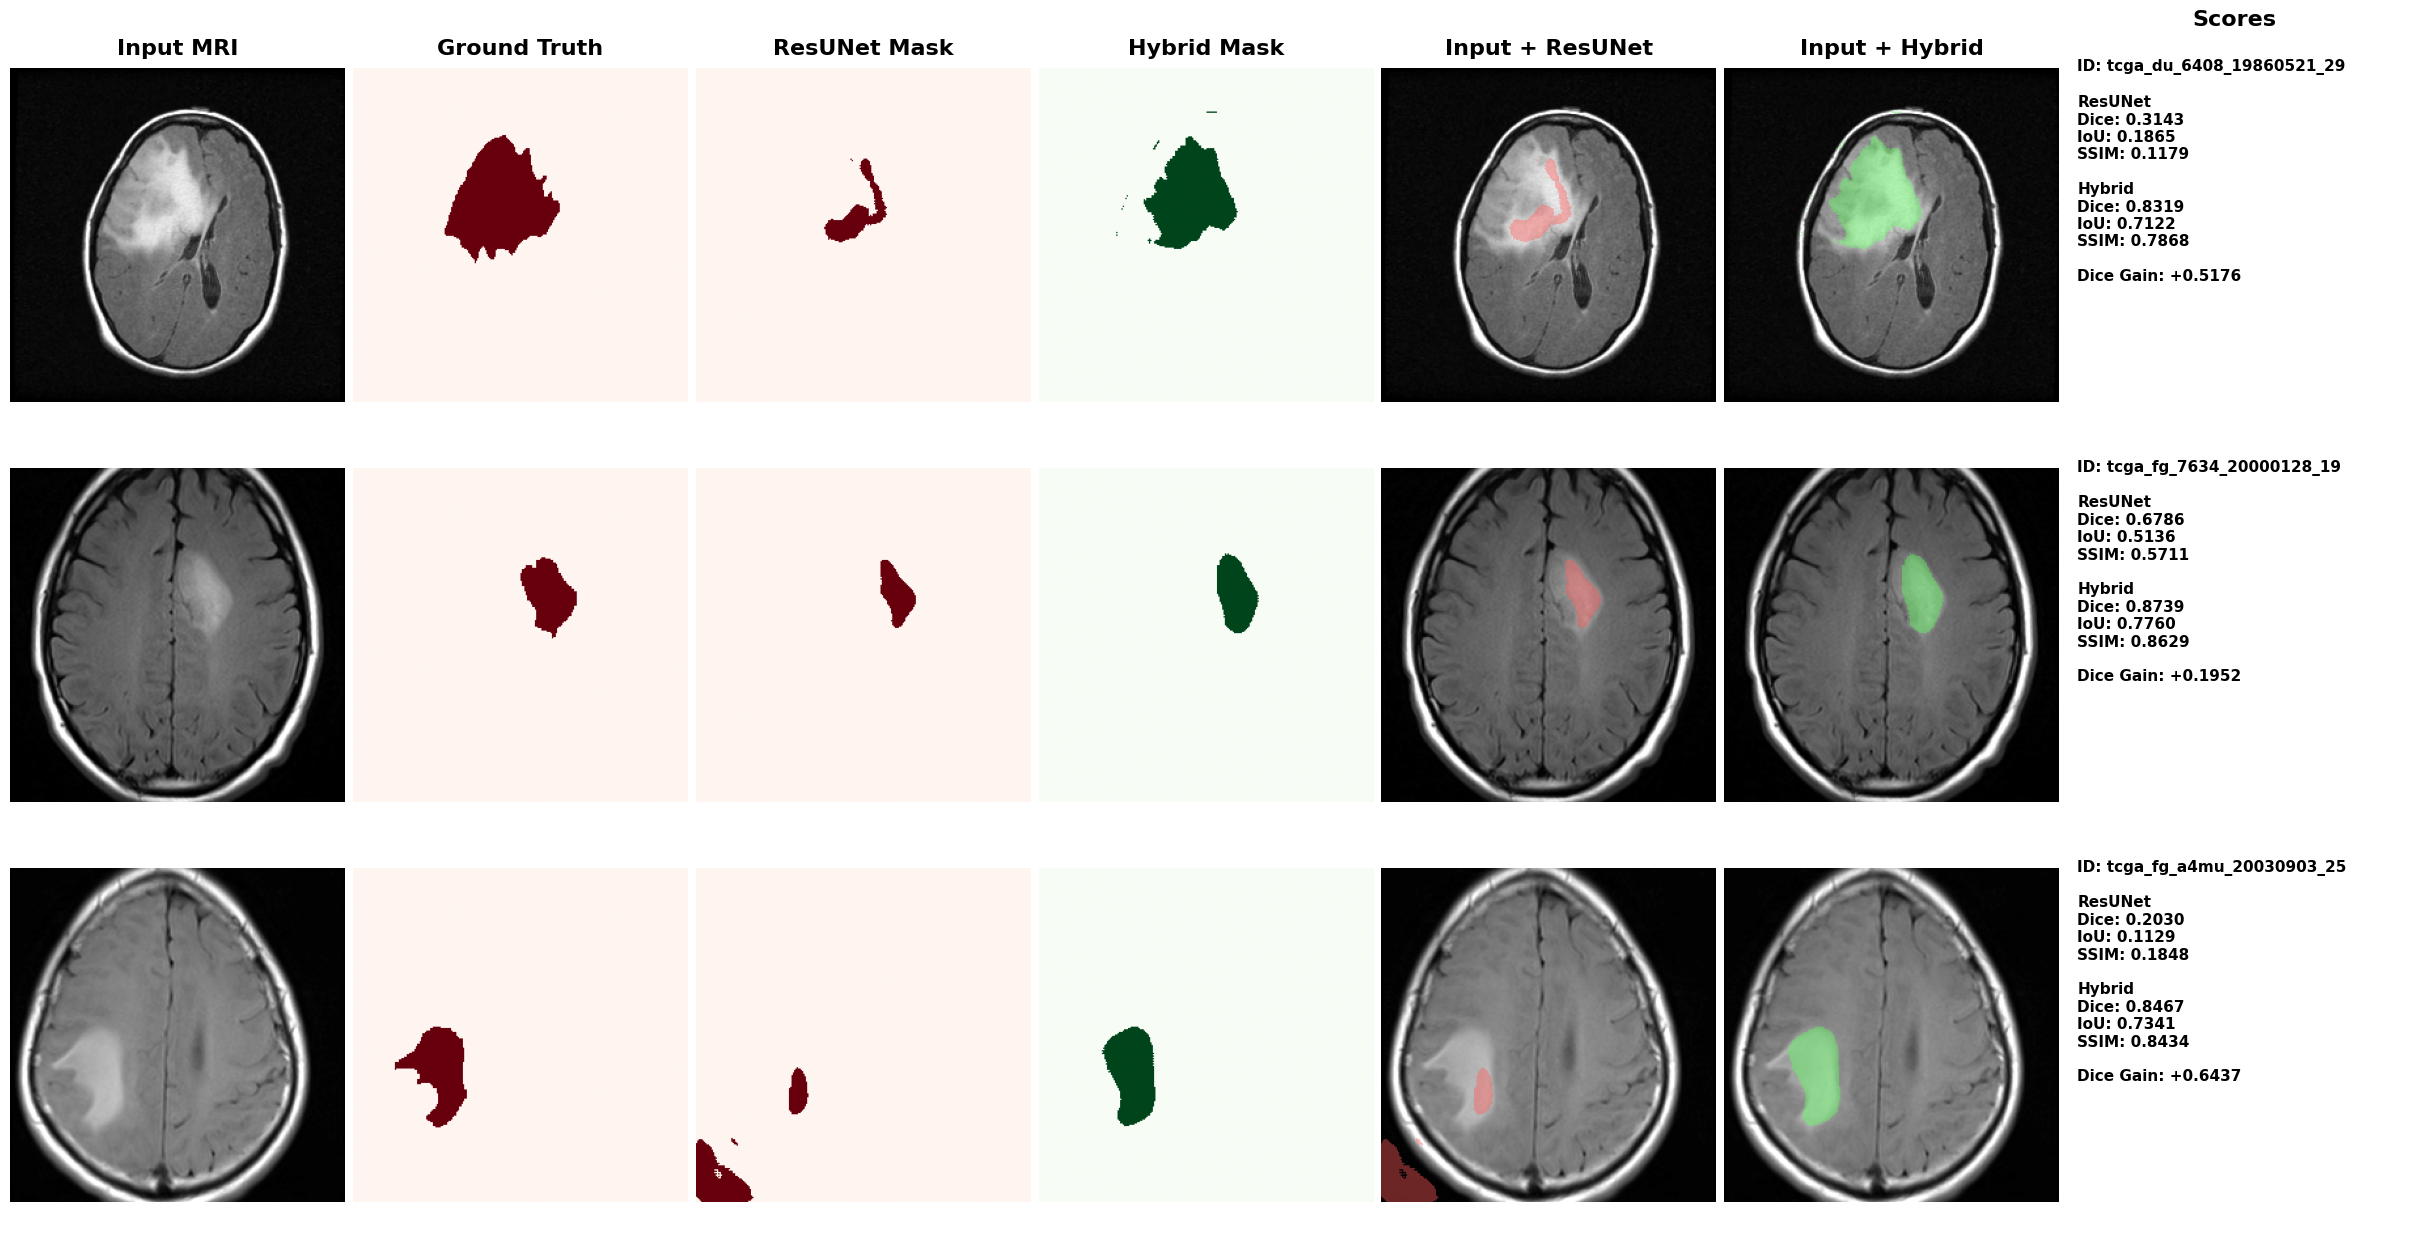

Saved: \content\brain_tumor_hybrid\final_figures_300dpi\comparison_grid_7col_random_3rows_300dpi.png
1. tcga_du_6408_19860521_29 | ResUNet Dice=0.3143 | Hybrid Dice=0.8319 | Dice Gain=+0.5176
2. tcga_fg_7634_20000128_19 | ResUNet Dice=0.6786 | Hybrid Dice=0.8739 | Dice Gain=+0.1952
3. tcga_fg_a4mu_20030903_25 | ResUNet Dice=0.2030 | Hybrid Dice=0.8467 | Dice Gain=+0.6437


In [21]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import cv2

from brain_tumor_hybrid_colab import (
    Config,
    prepare_kaggle_dataset,
    pair_images_and_masks,
    split_dataset,
    build_resunet,
    build_hybrid_model,
)

# =========================
# SETTINGS
# =========================
num_rows = 4
min_gt_pixels = 80
min_resunet_pixels = 40
min_hybrid_pixels = 60
min_resunet_dice = 0.10
min_hybrid_dice = 0.35
min_dice_gain = 0.02
random_seed = None  # set an int like 42 if you want repeatable rows

cfg = Config(
    kaggle_dataset="mateuszbuda/lgg-mri-segmentation",
    project_dir="/content/brain_tumor_hybrid",
    image_size=256,
)

save_dir = Path("/content/brain_tumor_hybrid/final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

if random_seed is not None:
    random.seed(random_seed)

# =========================
# HELPERS
# =========================
def dice_np(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).reshape(-1)
    target = target.astype(np.float32).reshape(-1)
    inter = (pred * target).sum()
    return float((2 * inter + eps) / (pred.sum() + target.sum() + eps))

def iou_np(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).reshape(-1)
    target = target.astype(np.float32).reshape(-1)
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return float((inter + eps) / (union + eps))

def ssim_np(pred, target, c1=0.01**2, c2=0.03**2):
    pred = pred.astype(np.float32)
    target = target.astype(np.float32)

    mu_x = pred.mean()
    mu_y = target.mean()
    sigma_x = ((pred - mu_x) ** 2).mean()
    sigma_y = ((target - mu_y) ** 2).mean()
    sigma_xy = ((pred - mu_x) * (target - mu_y)).mean()

    num = (2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)
    den = (mu_x**2 + mu_y**2 + c1) * (sigma_x + sigma_y + c2)
    return float(num / den)

def normalize_gray(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

def pad_to_square(img, fill=0):
    h, w = img.shape[:2]
    if h == w:
        return img

    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if img.ndim == 2:
        value = fill
    else:
        value = [fill] * img.shape[2]

    return cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=value)

def ensure_gray(img):
    if img is None:
        return None
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[2] == 1:
            return img[:, :, 0]
        if img.shape[2] == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if img.shape[2] == 4:
            return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    raise ValueError(f"Unsupported image shape: {img.shape}")

def gray_to_rgb(img):
    img = ensure_gray(img)
    return np.stack([img, img, img], axis=-1)

def overlay_mask(gray_img, mask, color=(0, 255, 0), alpha=0.45):
    gray_img = normalize_gray(gray_img)
    gray_rgb = np.stack([gray_img, gray_img, gray_img], axis=-1)
    gray_rgb = (gray_rgb * 255).astype(np.uint8)

    overlay = gray_rgb.copy()
    mask = mask.astype(bool)

    overlay[mask] = (
        (1 - alpha) * overlay[mask] + alpha * np.array(color, dtype=np.uint8)
    ).astype(np.uint8)

    return overlay

# =========================
# DATA
# =========================
images_dir, masks_dir = prepare_kaggle_dataset(cfg)
cfg.raw_images_dir = str(images_dir)
cfg.raw_masks_dir = str(masks_dir)

df = pair_images_and_masks(Path(cfg.raw_images_dir), Path(cfg.raw_masks_dir), cfg.mask_suffixes)
split_frames = split_dataset(df, cfg)
test_df = split_frames["test"].reset_index(drop=True)

# =========================
# LOAD MODELS
# =========================
resunet_model = build_resunet(cfg).to(cfg.device)
resunet_ckpt = "/content/brain_tumor_hybrid/artifacts/baseline_resunet/best_model.pt"
resunet_model.load_state_dict(torch.load(resunet_ckpt, map_location=cfg.device, weights_only=True))
resunet_model.eval()

hybrid_model = build_hybrid_model(cfg).to(cfg.device)
hybrid_ckpt = "/content/brain_tumor_hybrid/artifacts/hybrid_attention_unet_effb4/best_model.pt"
hybrid_model.load_state_dict(torch.load(hybrid_ckpt, map_location=cfg.device, weights_only=True))
hybrid_model.eval()

# =========================
# COLLECT ELIGIBLE SAMPLES
# =========================
eligible_samples = []

with torch.no_grad():
    for _, row in test_df.iterrows():
        img_path = row["image_path"]
        mask_path = row["mask_path"]
        sample_id = row["id"]

        orig_gray = ensure_gray(cv2.imread(img_path, cv2.IMREAD_UNCHANGED))
        gt = ensure_gray(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED))

        if orig_gray is None or gt is None:
            continue

        gt = (gt > 0).astype(np.uint8)

        if gt.sum() < min_gt_pixels:
            continue

        input_display = normalize_gray(orig_gray)

        model_img = gray_to_rgb(orig_gray)
        model_img = pad_to_square(model_img, fill=0)
        gt_sq = pad_to_square(gt, fill=0)
        input_sq = pad_to_square(input_display, fill=0)

        model_img = cv2.resize(model_img, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_LINEAR)
        gt_sq = cv2.resize(gt_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_NEAREST)
        input_sq = cv2.resize(input_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_LINEAR)

        x = model_img.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        x = (x - mean) / std
        x = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0).to(cfg.device)

        resunet_prob = torch.sigmoid(resunet_model(x)).squeeze().cpu().numpy()
        hybrid_prob = torch.sigmoid(hybrid_model(x)).squeeze().cpu().numpy()

        resunet_pred = (resunet_prob > cfg.threshold).astype(np.uint8)
        hybrid_pred = (hybrid_prob > cfg.threshold).astype(np.uint8)

        if resunet_pred.sum() < min_resunet_pixels:
            continue
        if hybrid_pred.sum() < min_hybrid_pixels:
            continue

        resunet_dice = dice_np(resunet_pred, gt_sq)
        hybrid_dice = dice_np(hybrid_pred, gt_sq)

        if resunet_dice < min_resunet_dice:
            continue
        if hybrid_dice < min_hybrid_dice:
            continue

        resunet_iou = iou_np(resunet_pred, gt_sq)
        hybrid_iou = iou_np(hybrid_pred, gt_sq)

        resunet_ssim = ssim_np(resunet_pred, gt_sq)
        hybrid_ssim = ssim_np(hybrid_pred, gt_sq)

        dice_gain = hybrid_dice - resunet_dice

        if dice_gain < min_dice_gain:
            continue

        overlay_resunet = overlay_mask(input_sq, resunet_pred, color=(255, 90, 90), alpha=0.42)
        overlay_hybrid = overlay_mask(input_sq, hybrid_pred, color=(90, 255, 90), alpha=0.42)

        eligible_samples.append({
            "id": sample_id,
            "input": input_sq,
            "gt": gt_sq,
            "resunet_pred": resunet_pred,
            "hybrid_pred": hybrid_pred,
            "overlay_resunet": overlay_resunet,
            "overlay_hybrid": overlay_hybrid,
            "resunet_dice": resunet_dice,
            "hybrid_dice": hybrid_dice,
            "resunet_iou": resunet_iou,
            "hybrid_iou": hybrid_iou,
            "resunet_ssim": resunet_ssim,
            "hybrid_ssim": hybrid_ssim,
            "dice_gain": dice_gain,
        })

if len(eligible_samples) == 0:
    raise RuntimeError(
        "No eligible samples found where both ResUNet and Hybrid masks are visible. "
        "Lower min_resunet_pixels or min_resunet_dice."
    )

selected_count = min(num_rows, len(eligible_samples))
selected = random.sample(eligible_samples, selected_count)

print("Eligible samples:", len(eligible_samples))
print("Selected rows:", len(selected))

# =========================
# 7-COLUMN FIGURE
# =========================
fig, axes = plt.subplots(
    len(selected),
    7,
    figsize=(24, 4.1 * len(selected)),
    constrained_layout=True
)

if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

headers = [
    "Input MRI",
    "Ground Truth",
    "ResUNet Mask",
    "Hybrid Mask",
    "Input + ResUNet",
    "Input + Hybrid",
    "Scores",
]

for j, header in enumerate(headers):
    axes[0, j].set_title(header, fontsize=16, fontweight="bold", pad=10)

for i, sample in enumerate(selected):
    axes[i, 0].imshow(sample["input"], cmap="gray")
    axes[i, 1].imshow(sample["gt"], cmap="Reds", vmin=0, vmax=1)
    axes[i, 2].imshow(sample["resunet_pred"], cmap="Reds", vmin=0, vmax=1)
    axes[i, 3].imshow(sample["hybrid_pred"], cmap="Greens", vmin=0, vmax=1)
    axes[i, 4].imshow(sample["overlay_resunet"])
    axes[i, 5].imshow(sample["overlay_hybrid"])

    score_text = (
        f"ID: {sample['id']}\n\n"
        f"ResUNet\n"
        f"Dice: {sample['resunet_dice']:.4f}\n"
        f"IoU: {sample['resunet_iou']:.4f}\n"
        f"SSIM: {sample['resunet_ssim']:.4f}\n\n"
        f"Hybrid\n"
        f"Dice: {sample['hybrid_dice']:.4f}\n"
        f"IoU: {sample['hybrid_iou']:.4f}\n"
        f"SSIM: {sample['hybrid_ssim']:.4f}\n\n"
        f"Dice Gain: {sample['dice_gain']:+.4f}"
    )

    axes[i, 6].text(
        0.03,
        0.95,
        score_text,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        family="sans-serif",
    )
    axes[i, 6].axis("off")

    for j in range(6):
        axes[i, j].axis("off")

out_path = save_dir / f"comparison_grid_7col_random_{len(selected)}rows_300dpi.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_path)
for idx, sample in enumerate(selected, 1):
    print(
        f"{idx}. {sample['id']} | "
        f"ResUNet Dice={sample['resunet_dice']:.4f} | "
        f"Hybrid Dice={sample['hybrid_dice']:.4f} | "
        f"Dice Gain={sample['dice_gain']:+.4f}"
    )

Prepared images: \content\kaggle_data\lgg_mri_segmentation\_prepared_images
Prepared masks: \content\kaggle_data\lgg_mri_segmentation\_prepared_masks
Eligible samples: 6
Selected rows: 4


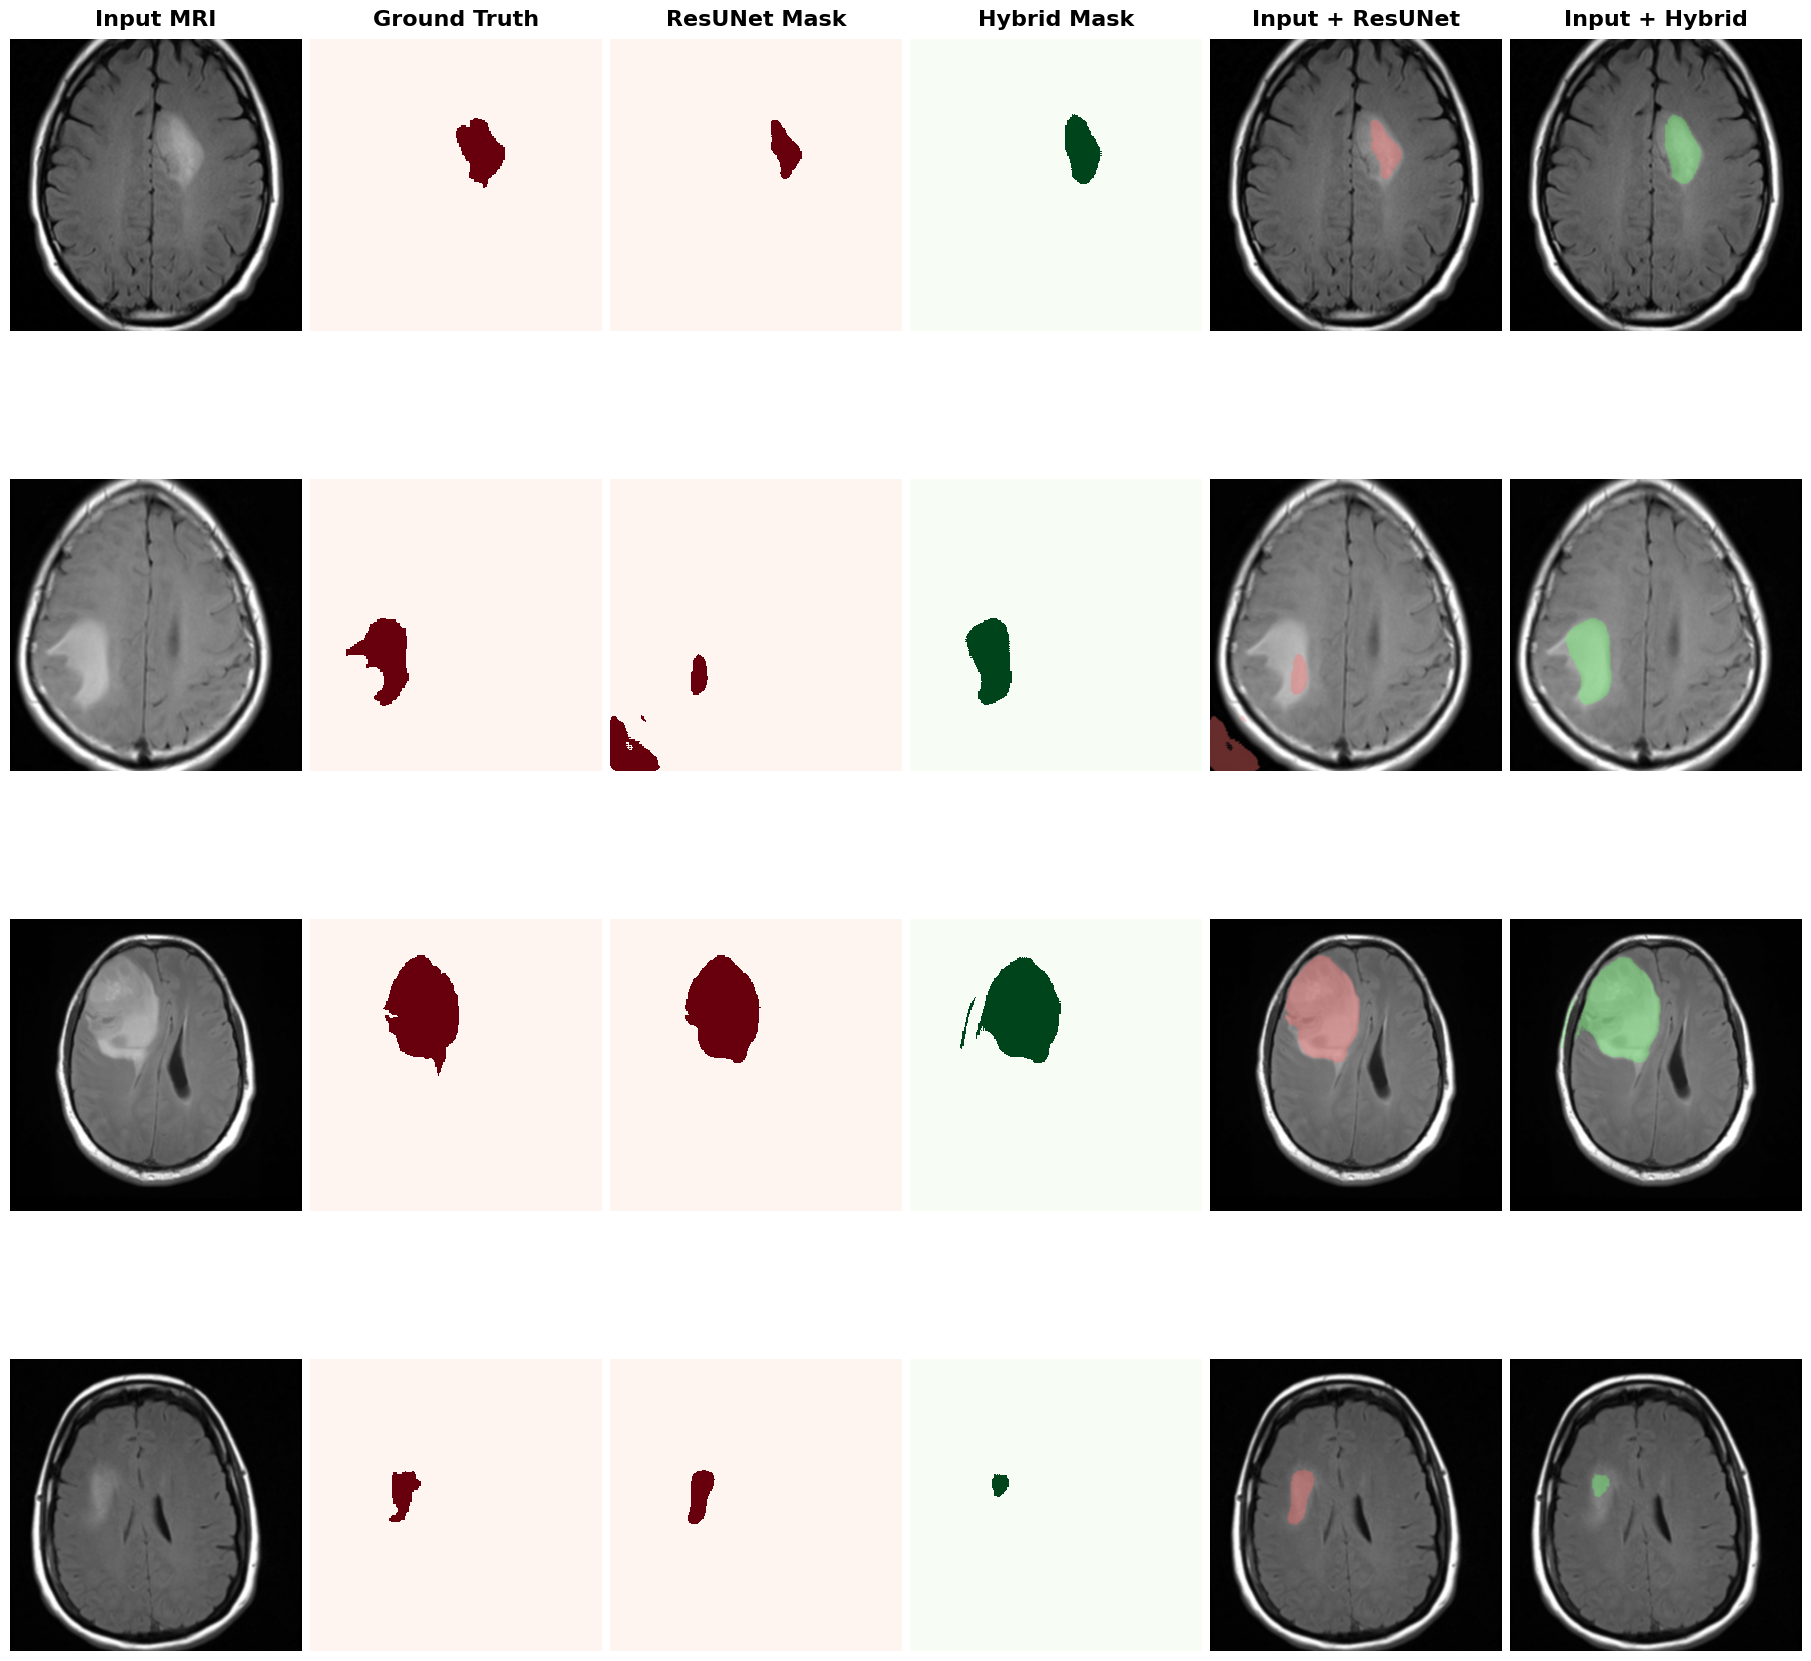

Saved: \content\brain_tumor_hybrid\final_figures_300dpi\comparison_grid_6col_clean_4images_300dpi.png
1. tcga_fg_7634_20000128_19 | ResUNet Dice=0.6786 | Hybrid Dice=0.8739
2. tcga_fg_a4mu_20030903_25 | ResUNet Dice=0.2030 | Hybrid Dice=0.8467
3. tcga_ht_7690_19960312_16 | ResUNet Dice=0.9674 | Hybrid Dice=0.9453
4. tcga_fg_8189_20030516_35 | ResUNet Dice=0.8153 | Hybrid Dice=0.4665


In [22]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import cv2

from brain_tumor_hybrid_colab import (
    Config,
    prepare_kaggle_dataset,
    pair_images_and_masks,
    split_dataset,
    build_resunet,
    build_hybrid_model,
)

# =========================
# SETTINGS
# =========================
num_rows = 4
min_gt_pixels = 80
min_resunet_pixels = 20
min_hybrid_pixels = 40
min_resunet_dice = 0.05
min_hybrid_dice = 0.20
random_seed = None   # put 42 if you want same images every time

cfg = Config(
    kaggle_dataset="mateuszbuda/lgg-mri-segmentation",
    project_dir="/content/brain_tumor_hybrid",
    image_size=256,
)

save_dir = Path("/content/brain_tumor_hybrid/final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

if random_seed is not None:
    random.seed(random_seed)

# =========================
# HELPERS
# =========================
def dice_np(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).reshape(-1)
    target = target.astype(np.float32).reshape(-1)
    inter = (pred * target).sum()
    return float((2 * inter + eps) / (pred.sum() + target.sum() + eps))

def normalize_gray(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

def pad_to_square(img, fill=0):
    h, w = img.shape[:2]
    if h == w:
        return img

    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if img.ndim == 2:
        value = fill
    else:
        value = [fill] * img.shape[2]

    return cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=value)

def ensure_gray(img):
    if img is None:
        return None
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[2] == 1:
            return img[:, :, 0]
        if img.shape[2] == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if img.shape[2] == 4:
            return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    raise ValueError(f"Unsupported image shape: {img.shape}")

def gray_to_rgb(img):
    img = ensure_gray(img)
    return np.stack([img, img, img], axis=-1)

def overlay_mask(gray_img, mask, color=(0, 255, 0), alpha=0.42):
    gray_img = normalize_gray(gray_img)
    gray_rgb = np.stack([gray_img, gray_img, gray_img], axis=-1)
    gray_rgb = (gray_rgb * 255).astype(np.uint8)

    overlay = gray_rgb.copy()
    mask = mask.astype(bool)

    overlay[mask] = (
        (1 - alpha) * overlay[mask] + alpha * np.array(color, dtype=np.uint8)
    ).astype(np.uint8)

    return overlay

# =========================
# DATA
# =========================
images_dir, masks_dir = prepare_kaggle_dataset(cfg)
cfg.raw_images_dir = str(images_dir)
cfg.raw_masks_dir = str(masks_dir)

df = pair_images_and_masks(Path(cfg.raw_images_dir), Path(cfg.raw_masks_dir), cfg.mask_suffixes)
split_frames = split_dataset(df, cfg)
test_df = split_frames["test"].reset_index(drop=True)

# =========================
# LOAD MODELS
# =========================
resunet_model = build_resunet(cfg).to(cfg.device)
resunet_ckpt = "/content/brain_tumor_hybrid/artifacts/baseline_resunet/best_model.pt"
resunet_model.load_state_dict(torch.load(resunet_ckpt, map_location=cfg.device, weights_only=True))
resunet_model.eval()

hybrid_model = build_hybrid_model(cfg).to(cfg.device)
hybrid_ckpt = "/content/brain_tumor_hybrid/artifacts/hybrid_attention_unet_effb4/best_model.pt"
hybrid_model.load_state_dict(torch.load(hybrid_ckpt, map_location=cfg.device, weights_only=True))
hybrid_model.eval()

# =========================
# COLLECT ELIGIBLE SAMPLES
# =========================
eligible_samples = []

with torch.no_grad():
    for _, row in test_df.iterrows():
        img_path = row["image_path"]
        mask_path = row["mask_path"]
        sample_id = row["id"]

        orig_gray = ensure_gray(cv2.imread(img_path, cv2.IMREAD_UNCHANGED))
        gt = ensure_gray(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED))

        if orig_gray is None or gt is None:
            continue

        gt = (gt > 0).astype(np.uint8)

        if gt.sum() < min_gt_pixels:
            continue

        input_display = normalize_gray(orig_gray)

        model_img = gray_to_rgb(orig_gray)
        model_img = pad_to_square(model_img, fill=0)
        gt_sq = pad_to_square(gt, fill=0)
        input_sq = pad_to_square(input_display, fill=0)

        # Better visual quality for display
        model_img = cv2.resize(model_img, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_CUBIC)
        gt_sq = cv2.resize(gt_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_NEAREST)
        input_sq = cv2.resize(input_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_CUBIC)

        x = model_img.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        x = (x - mean) / std
        x = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0).to(cfg.device)

        resunet_prob = torch.sigmoid(resunet_model(x)).squeeze().cpu().numpy()
        hybrid_prob = torch.sigmoid(hybrid_model(x)).squeeze().cpu().numpy()

        resunet_pred = (resunet_prob > cfg.threshold).astype(np.uint8)
        hybrid_pred = (hybrid_prob > cfg.threshold).astype(np.uint8)

        if resunet_pred.sum() < min_resunet_pixels:
            continue
        if hybrid_pred.sum() < min_hybrid_pixels:
            continue

        resunet_dice = dice_np(resunet_pred, gt_sq)
        hybrid_dice = dice_np(hybrid_pred, gt_sq)

        if resunet_dice < min_resunet_dice:
            continue
        if hybrid_dice < min_hybrid_dice:
            continue

        overlay_resunet = overlay_mask(input_sq, resunet_pred, color=(255, 110, 110), alpha=0.40)
        overlay_hybrid = overlay_mask(input_sq, hybrid_pred, color=(110, 255, 110), alpha=0.40)

        eligible_samples.append({
            "id": sample_id,
            "input": input_sq,
            "gt": gt_sq,
            "resunet_pred": resunet_pred,
            "hybrid_pred": hybrid_pred,
            "overlay_resunet": overlay_resunet,
            "overlay_hybrid": overlay_hybrid,
            "resunet_dice": resunet_dice,
            "hybrid_dice": hybrid_dice,
        })

if len(eligible_samples) == 0:
    raise RuntimeError(
        "No eligible samples found. Lower min_resunet_pixels, min_hybrid_pixels, or dice filters."
    )

selected_count = min(num_rows, len(eligible_samples))
selected = random.sample(eligible_samples, selected_count)

print("Eligible samples:", len(eligible_samples))
print("Selected rows:", len(selected))

# =========================
# 6-COLUMN FIGURE
# =========================
fig, axes = plt.subplots(
    len(selected),
    6,
    figsize=(18, 4.4 * len(selected)),
    constrained_layout=True
)

if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

headers = [
    "Input MRI",
    "Ground Truth",
    "ResUNet Mask",
    "Hybrid Mask",
    "Input + ResUNet",
    "Input + Hybrid",
]

for j, header in enumerate(headers):
    axes[0, j].set_title(header, fontsize=16, fontweight="bold", pad=10)

for i, sample in enumerate(selected):
    axes[i, 0].imshow(sample["input"], cmap="gray", interpolation="bicubic")
    axes[i, 1].imshow(sample["gt"], cmap="Reds", vmin=0, vmax=1, interpolation="nearest")
    axes[i, 2].imshow(sample["resunet_pred"], cmap="Reds", vmin=0, vmax=1, interpolation="nearest")
    axes[i, 3].imshow(sample["hybrid_pred"], cmap="Greens", vmin=0, vmax=1, interpolation="nearest")
    axes[i, 4].imshow(sample["overlay_resunet"], interpolation="bicubic")
    axes[i, 5].imshow(sample["overlay_hybrid"], interpolation="bicubic")

    for j in range(6):
        axes[i, j].axis("off")

out_path = save_dir / f"comparison_grid_6col_clean_4images_300dpi.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_path)
for idx, sample in enumerate(selected, 1):
    print(
        f"{idx}. {sample['id']} | "
        f"ResUNet Dice={sample['resunet_dice']:.4f} | "
        f"Hybrid Dice={sample['hybrid_dice']:.4f}"
    )

Prepared images: \content\kaggle_data\lgg_mri_segmentation\_prepared_images
Prepared masks: \content\kaggle_data\lgg_mri_segmentation\_prepared_masks
Eligible strong samples: 3
Selected rows: 3


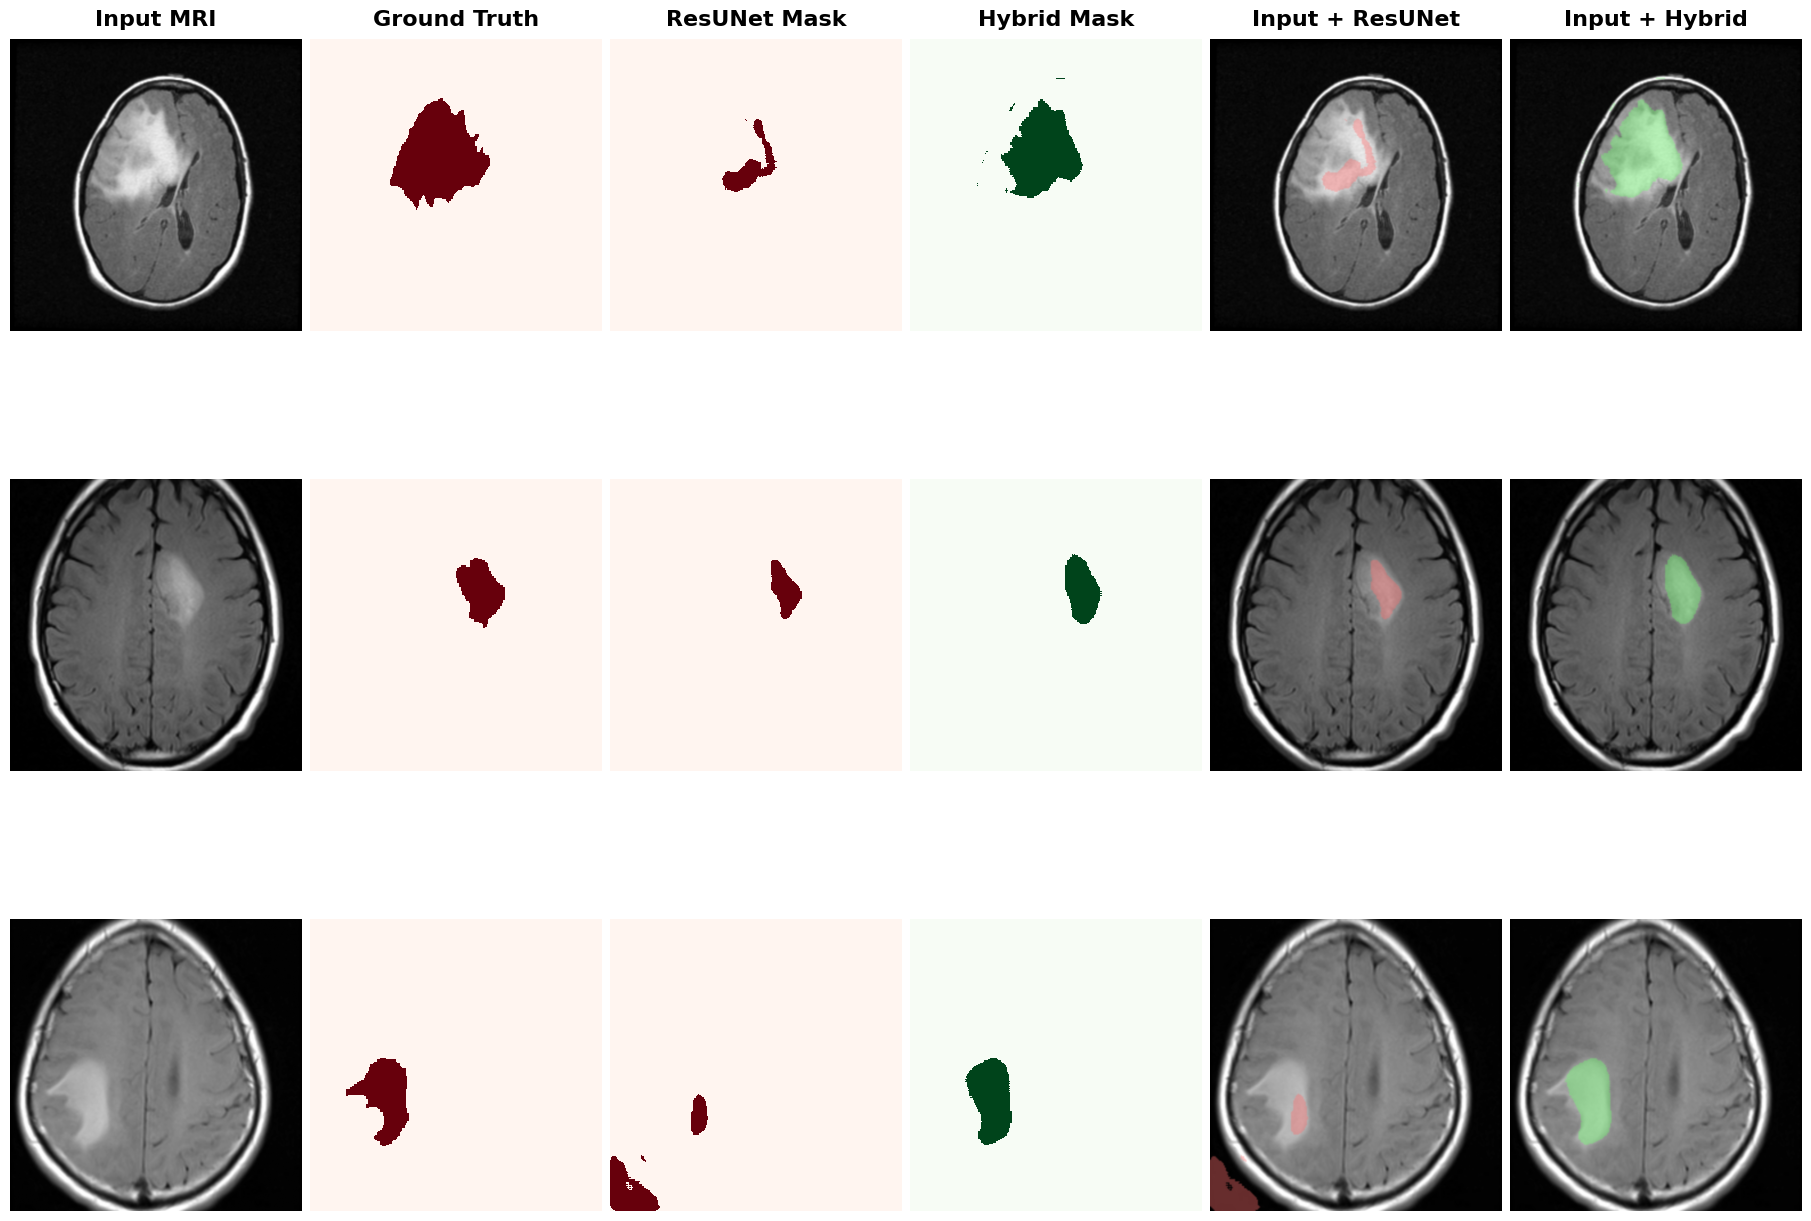

Saved: \content\brain_tumor_hybrid\final_figures_300dpi\comparison_grid_6col_better_hybrid_4images_300dpi.png
1. tcga_du_6408_19860521_29 | ResUNet Dice=0.3143 | Hybrid Dice=0.8319 | Dice Gain=+0.5176
2. tcga_fg_7634_20000128_19 | ResUNet Dice=0.6786 | Hybrid Dice=0.8739 | Dice Gain=+0.1952
3. tcga_fg_a4mu_20030903_25 | ResUNet Dice=0.2030 | Hybrid Dice=0.8467 | Dice Gain=+0.6437


In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import cv2

from brain_tumor_hybrid_colab import (
    Config,
    prepare_kaggle_dataset,
    pair_images_and_masks,
    split_dataset,
    build_resunet,
    build_hybrid_model,
)

# =========================
# SETTINGS
# =========================
num_rows = 4
min_gt_pixels = 100
min_resunet_pixels = 20
min_hybrid_pixels = 80
min_resunet_dice = 0.03
min_hybrid_dice = 0.55
min_dice_gain = 0.12
random_seed = None   # set 42 if you want fixed rows

cfg = Config(
    kaggle_dataset="mateuszbuda/lgg-mri-segmentation",
    project_dir="/content/brain_tumor_hybrid",
    image_size=256,
)

save_dir = Path("/content/brain_tumor_hybrid/final_figures_300dpi")
save_dir.mkdir(parents=True, exist_ok=True)

if random_seed is not None:
    random.seed(random_seed)

# =========================
# HELPERS
# =========================
def dice_np(pred, target, eps=1e-6):
    pred = pred.astype(np.float32).reshape(-1)
    target = target.astype(np.float32).reshape(-1)
    inter = (pred * target).sum()
    return float((2 * inter + eps) / (pred.sum() + target.sum() + eps))

def normalize_gray(img):
    img = img.astype(np.float32)
    p1, p99 = np.percentile(img, (1, 99))
    img = np.clip(img, p1, p99)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return img

def pad_to_square(img, fill=0):
    h, w = img.shape[:2]
    if h == w:
        return img

    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if img.ndim == 2:
        value = fill
    else:
        value = [fill] * img.shape[2]

    return cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=value)

def ensure_gray(img):
    if img is None:
        return None
    if img.ndim == 2:
        return img
    if img.ndim == 3:
        if img.shape[2] == 1:
            return img[:, :, 0]
        if img.shape[2] == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if img.shape[2] == 4:
            return cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
    raise ValueError(f"Unsupported image shape: {img.shape}")

def gray_to_rgb(img):
    img = ensure_gray(img)
    return np.stack([img, img, img], axis=-1)

def overlay_mask(gray_img, mask, color=(0, 255, 0), alpha=0.42):
    gray_img = normalize_gray(gray_img)
    gray_rgb = np.stack([gray_img, gray_img, gray_img], axis=-1)
    gray_rgb = (gray_rgb * 255).astype(np.uint8)

    overlay = gray_rgb.copy()
    mask = mask.astype(bool)

    overlay[mask] = (
        (1 - alpha) * overlay[mask] + alpha * np.array(color, dtype=np.uint8)
    ).astype(np.uint8)

    return overlay

# =========================
# DATA
# =========================
images_dir, masks_dir = prepare_kaggle_dataset(cfg)
cfg.raw_images_dir = str(images_dir)
cfg.raw_masks_dir = str(masks_dir)

df = pair_images_and_masks(Path(cfg.raw_images_dir), Path(cfg.raw_masks_dir), cfg.mask_suffixes)
split_frames = split_dataset(df, cfg)
test_df = split_frames["test"].reset_index(drop=True)

# =========================
# LOAD MODELS
# =========================
resunet_model = build_resunet(cfg).to(cfg.device)
resunet_ckpt = "/content/brain_tumor_hybrid/artifacts/baseline_resunet/best_model.pt"
resunet_model.load_state_dict(torch.load(resunet_ckpt, map_location=cfg.device, weights_only=True))
resunet_model.eval()

hybrid_model = build_hybrid_model(cfg).to(cfg.device)
hybrid_ckpt = "/content/brain_tumor_hybrid/artifacts/hybrid_attention_unet_effb4/best_model.pt"
hybrid_model.load_state_dict(torch.load(hybrid_ckpt, map_location=cfg.device, weights_only=True))
hybrid_model.eval()

# =========================
# COLLECT BEST HYBRID SAMPLES
# =========================
eligible_samples = []

with torch.no_grad():
    for _, row in test_df.iterrows():
        img_path = row["image_path"]
        mask_path = row["mask_path"]
        sample_id = row["id"]

        orig_gray = ensure_gray(cv2.imread(img_path, cv2.IMREAD_UNCHANGED))
        gt = ensure_gray(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED))

        if orig_gray is None or gt is None:
            continue

        gt = (gt > 0).astype(np.uint8)

        if gt.sum() < min_gt_pixels:
            continue

        input_display = normalize_gray(orig_gray)

        model_img = gray_to_rgb(orig_gray)
        model_img = pad_to_square(model_img, fill=0)
        gt_sq = pad_to_square(gt, fill=0)
        input_sq = pad_to_square(input_display, fill=0)

        model_img = cv2.resize(model_img, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_CUBIC)
        gt_sq = cv2.resize(gt_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_NEAREST)
        input_sq = cv2.resize(input_sq, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_CUBIC)

        x = model_img.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        x = (x - mean) / std
        x = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0).to(cfg.device)

        resunet_prob = torch.sigmoid(resunet_model(x)).squeeze().cpu().numpy()
        hybrid_prob = torch.sigmoid(hybrid_model(x)).squeeze().cpu().numpy()

        resunet_pred = (resunet_prob > cfg.threshold).astype(np.uint8)
        hybrid_pred = (hybrid_prob > cfg.threshold).astype(np.uint8)

        if resunet_pred.sum() < min_resunet_pixels:
            continue
        if hybrid_pred.sum() < min_hybrid_pixels:
            continue

        resunet_dice = dice_np(resunet_pred, gt_sq)
        hybrid_dice = dice_np(hybrid_pred, gt_sq)
        dice_gain = hybrid_dice - resunet_dice

        if resunet_dice < min_resunet_dice:
            continue
        if hybrid_dice < min_hybrid_dice:
            continue
        if dice_gain < min_dice_gain:
            continue

        overlay_resunet = overlay_mask(input_sq, resunet_pred, color=(255, 110, 110), alpha=0.40)
        overlay_hybrid = overlay_mask(input_sq, hybrid_pred, color=(110, 255, 110), alpha=0.40)

        eligible_samples.append({
            "id": sample_id,
            "input": input_sq,
            "gt": gt_sq,
            "resunet_pred": resunet_pred,
            "hybrid_pred": hybrid_pred,
            "overlay_resunet": overlay_resunet,
            "overlay_hybrid": overlay_hybrid,
            "resunet_dice": resunet_dice,
            "hybrid_dice": hybrid_dice,
            "dice_gain": dice_gain,
        })

if len(eligible_samples) == 0:
    raise RuntimeError(
        "No strong hybrid samples found. Lower min_hybrid_dice or min_dice_gain."
    )

# sort by best hybrid performance, then choose 4 random from top pool
eligible_samples = sorted(
    eligible_samples,
    key=lambda x: (x["hybrid_dice"], x["dice_gain"]),
    reverse=True
)

top_pool = eligible_samples[:min(20, len(eligible_samples))]
selected_count = min(num_rows, len(top_pool))
selected = random.sample(top_pool, selected_count)

print("Eligible strong samples:", len(eligible_samples))
print("Selected rows:", len(selected))

# =========================
# 6-COLUMN FIGURE
# =========================
fig, axes = plt.subplots(
    len(selected),
    6,
    figsize=(18, 4.4 * len(selected)),
    constrained_layout=True
)

if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

headers = [
    "Input MRI",
    "Ground Truth",
    "ResUNet Mask",
    "Hybrid Mask",
    "Input + ResUNet",
    "Input + Hybrid",
]

for j, header in enumerate(headers):
    axes[0, j].set_title(header, fontsize=16, fontweight="bold", pad=10)

for i, sample in enumerate(selected):
    axes[i, 0].imshow(sample["input"], cmap="gray", interpolation="bicubic")
    axes[i, 1].imshow(sample["gt"], cmap="Reds", vmin=0, vmax=1, interpolation="nearest")
    axes[i, 2].imshow(sample["resunet_pred"], cmap="Reds", vmin=0, vmax=1, interpolation="nearest")
    axes[i, 3].imshow(sample["hybrid_pred"], cmap="Greens", vmin=0, vmax=1, interpolation="nearest")
    axes[i, 4].imshow(sample["overlay_resunet"], interpolation="bicubic")
    axes[i, 5].imshow(sample["overlay_hybrid"], interpolation="bicubic")

    for j in range(6):
        axes[i, j].axis("off")

out_path = save_dir / "comparison_grid_6col_better_hybrid_4images_300dpi.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", out_path)
for idx, sample in enumerate(selected, 1):
    print(
        f"{idx}. {sample['id']} | "
        f"ResUNet Dice={sample['resunet_dice']:.4f} | "
        f"Hybrid Dice={sample['hybrid_dice']:.4f} | "
        f"Dice Gain={sample['dice_gain']:+.4f}"
    )

In [27]:
import os
print(os.getcwd())

C:\Users\HP\Downloads\brain_tumor_project
